# 05 — `solve_receding_horizon` test suite (intent-driven LP)

After the April 2026 refactor the optimiser controls **two continuous
loads** (EV charger and heater) and no longer schedules cycle-shaped
dishwasher / washing-machine starts. Those are *event-driven*: the user
starts them, and the agent only proposes a small forward shift via the
HITL gate.

Each scenario below isolates one aspect of the new formulation.

| # | Scenario | Feature under test |
|---|---|---|
| A | EV availability gate (no charging before 20:00) | C1 mask |
| B | EV deadline inside vs. outside horizon | C2 regimes |
| C | Heater per-window energy delivery | C3 (4 kWh by 07:00, 2 kWh by 18:00) |
| D | Heater shapes itself into the cheapest hour of the window | C3 + price valley |
| E | Power-cap binding between EV and heater | C5 |
| F | Committed dishwasher cycle as exogenous load | C5 + cap headroom |
| I | Stress: many simultaneous onsets (HITL throughput) | LangGraph + auto-responses |
| J | Horizon sensitivity (6 / 12 / 24 h) | LP scaling, savings vs. wall-time |
| K | Heater infeasibility → soft slack | C3 slack absorbs |
| L | Joint MIP vs price-only reschedule (cap binding) | C5 + C6 |
| M | Re-nudge before start (+1 h again) | Deferred-cycle replanning |


In [1]:
import sys, time, warnings
from pathlib import Path
from datetime import datetime, timedelta, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)

try:
    from IPython.display import display
except ImportError:
    display = print  # plain-script fallback

from aerogrid.optimizer import solve_receding_horizon
from aerogrid.commit import CommitTracker
from aerogrid.config import (
    APPLIANCES, EV_AVAILABLE_FROM_HOUR, EV_DEADLINE_HOUR, HEATER_DEADLINES,
    HITL_AUTO_RESPONSES, HOUSE_POWER_CAP_KW, HITL_RESCHEDULE_MIN_SAVINGS_EUR,
    HITL_RESCHEDULE_WINDOW_HOURS, SHORT_HORIZON_SLOTS, SLOT_MINUTES,
    HeaterEnergyDeadline,
)
from aerogrid.types import PendingCycle, RescheduleProposal, ScheduledTask
from aerogrid.graph import _propose_for_onset
from aerogrid.hitl_policy import decide_reschedule

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# ── constants ────────────────────────────────────────────────────────────────
SLOT_H = SLOT_MINUTES / 60          # 0.25 h per slot
_PER_SLOT = SLOT_H / 1000.0         # kW·(€/MWh) → € per slot

_PALETTE = {
    "ev_charger":      "#ff7f0e",
    "heater":          "#d62728",
    "dishwasher":      "#1f77b4",
    "washing_machine": "#2ca02c",
}


def _utc(h: int, m: int = 0, day: int = 15) -> datetime:
    return datetime(2026, 4, day, h, m, tzinfo=timezone.utc)


# ── shared plotting helper for continuous-load schedules ────────────────────
def _deadline_lines_in(t_start, t_end,
                      ev_hour=EV_DEADLINE_HOUR,
                      heater_deadlines=HEATER_DEADLINES):
    """Return [(t, label, color, ls)] for every deadline inside [t_start, t_end]."""
    out = []
    t = t_start.replace(hour=ev_hour, minute=0, second=0, microsecond=0)
    if t < t_start:
        t += timedelta(days=1)
    while t <= t_end:
        out.append((t, f"EV deadline {ev_hour:02d}:00", "#d62728", "--"))
        t += timedelta(days=1)
    for d in heater_deadlines:
        t = t_start.replace(hour=d.hour, minute=0, second=0, microsecond=0)
        if t < t_start:
            t += timedelta(days=1)
        while t <= t_end:
            out.append((t, f"heater {d.hour:02d}:00 ({d.kwh_required:.0f} kWh)",
                        "#9467bd", ":"))
            t += timedelta(days=1)
    return out


def plot_schedule(sched, prices, *, title="", cap_kw=HOUSE_POWER_CAP_KW, figsize=(13, 5.5)):
    """Stacked-bar load chart (top) + price step chart (bottom), datetime x-axis.

    EV and heater are shown as continuous-power bars. Committed cycle tasks
    (dishwasher / washing machine pinned by CommitTracker) appear hatched.
    Vertical dashed lines mark the EV deadline (red) and heater deadlines
    (purple) that fall inside the visible window.
    """
    T = sched.horizon_slots
    t0 = sched.slot_start
    times = [t0 + timedelta(minutes=SLOT_MINUTES * i) for i in range(T)]
    width_days = SLOT_MINUTES * 0.9 / (60.0 * 24.0)   # bar width in matplotlib date units
    prices = np.asarray(prices, dtype=float)

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [3, 2]},
    )
    bottom = np.zeros(T)

    ev = np.asarray(sched.ev_power_kw, dtype=float)
    heat = np.asarray(sched.heater_power_kw, dtype=float)

    ax1.bar(times, ev, width=width_days, bottom=bottom,
            color=_PALETTE["ev_charger"], alpha=0.85, label="EV (kW)", align="edge")
    bottom = bottom + ev
    ax1.bar(times, heat, width=width_days, bottom=bottom,
            color=_PALETTE["heater"], alpha=0.8, label="Heater (kW)", align="edge")
    bottom = bottom + heat

    seen: set = set()
    for task in sched.tasks:
        spec = APPLIANCES.get(task.appliance)
        if spec is None or not task.committed:
            continue
        run = np.zeros(T)
        for t in range(task.start_slot, min(task.start_slot + task.slots, T)):
            run[t] = spec.rated_kw
        color = _PALETTE.get(task.appliance, "#8c564b")
        label = (task.appliance + " [committed]") if task.appliance not in seen else None
        ax1.bar(times, run, width=width_days, bottom=bottom,
                color=color, alpha=0.7, label=label, hatch="//", align="edge")
        bottom = bottom + run
        seen.add(task.appliance)

    ax1.axhline(cap_kw, color="black", ls="--", lw=1.5, label=f"Cap {cap_kw} kW")
    ax1.set_ylabel("load (kW)")
    ax1.set_ylim(0, cap_kw * 1.3)
    ax1.set_title(title or "Optimizer schedule", fontsize=11)

    ann = (
        f"Cost €{sched.expected_cost:.4f}  ·  "
        f"Baseline €{sched.baseline_cost:.4f}  ·  "
        f"Savings {sched.savings()*100:.1f}%  ·  "
        f"Solver {sched.solver_status}"
    )
    if sched.heater_window_kwh:
        ann += "  ·  heater " + ", ".join(
            f"{h:02d}:{int(round(k*1000)):d}Wh" for h, k in sched.heater_window_kwh.items()
        )
    ax1.text(0.01, 0.98, ann, transform=ax1.transAxes, va="top", fontsize=7.5,
             bbox=dict(boxstyle="round,pad=0.25", fc="lightyellow", ec="#cca300", alpha=0.9))

    ax2.step(times, prices[:T], where="post", color="k", lw=1.4, label="Price (€/MWh)")
    ax2.fill_between(times, prices[:T], step="post", alpha=0.12, color="k")
    ax2.set_ylabel("€/MWh")
    ax2.set_xlabel("time of day (UTC)")

    # Deadline overlays + datetime formatting (after data is drawn so x-limits are set).
    t_end = times[-1] + timedelta(minutes=SLOT_MINUTES)
    seen_kinds: dict = {}
    for t, label, color, ls in _deadline_lines_in(t0, t_end):
        seen_kinds.setdefault(label, (color, ls))
        for ax in (ax1, ax2):
            ax.axvline(t, color=color, ls=ls, lw=1.1, alpha=0.7)
    handles_ax1, labels_ax1 = ax1.get_legend_handles_labels()
    for label, (color, ls) in seen_kinds.items():
        handles_ax1.append(plt.Line2D([0], [0], color=color, ls=ls, lw=1.1, label=label))
        labels_ax1.append(label)
    ax1.legend(handles_ax1, labels_ax1, loc="upper right", fontsize=7.6, ncol=2)
    ax2.legend(fontsize=8, loc="upper right")

    span_h = (t_end - t0).total_seconds() / 3600.0
    if span_h <= 12:
        loc = mdates.HourLocator(interval=1)
    elif span_h <= 36:
        loc = mdates.HourLocator(interval=3)
    else:
        loc = mdates.HourLocator(interval=6)
    ax2.xaxis.set_major_locator(loc)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")

    plt.tight_layout()
    return fig


def make_de_price_curve(seed: int = 42, base: float = 55.0, peak1_h: float = 8.0,
                        peak2_h: float = 18.0, n: int = 96) -> np.ndarray:
    """Synthetic 24 h DE-style price profile, deterministic given seed."""
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 24, n, endpoint=False)
    prices = (
        base
        + 35 * np.sin(2 * np.pi * (t - peak1_h) / 24)
        + 30 * np.exp(-0.5 * ((t - peak1_h) / 1.5) ** 2)
        + 25 * np.exp(-0.5 * ((t - peak2_h) / 1.5) ** 2)
        + 6 * rng.standard_normal(n)
    ).clip(10, 200)
    return prices


print(f"✓ helpers loaded  ·  horizon={SHORT_HORIZON_SLOTS} slots ({SHORT_HORIZON_SLOTS*SLOT_H:.0f} h)  ·  cap={HOUSE_POWER_CAP_KW} kW")
print(f"✓ EV window {EV_AVAILABLE_FROM_HOUR:02d}:00 → {EV_DEADLINE_HOUR:02d}:00 UTC")
print(f"✓ Heater deadlines: " + ", ".join(f"{d.kwh_required} kWh by {d.hour:02d}:00" for d in HEATER_DEADLINES))


✓ helpers loaded  ·  horizon=96 slots (24 h)  ·  cap=10.0 kW
✓ EV window 20:00 → 07:00 UTC
✓ Heater deadlines: 4.0 kWh by 07:00, 2.0 kWh by 18:00


## Scenario A — EV availability gate

The EV is only pluggable from `EV_AVAILABLE_FROM_HOUR = 20:00` UTC each day
until the next `EV_DEADLINE_HOUR = 07:00` UTC. Calling the optimiser at
**14:00 UTC** with a 24 h horizon, every slot from 14:00 → 19:45 must have
zero EV power.

Inside the 11 h overnight window the LP picks the cheapest hours to deliver
the full 24 kWh need. The heater meanwhile satisfies its overnight 4 kWh
deadline (window: 18:00 → 07:00) and the daytime 2 kWh deadline (window:
07:00 → 18:00).


EV [14:00–20:00] kWh = 0.000  (must be 0)
EV [20:00–07:00] kWh = 24.000  (full need)
EV [07:00–14:00] kWh = 0.000  (must be 0)
Heater windows  kWh = {7: 4.0, 18: 2.0}


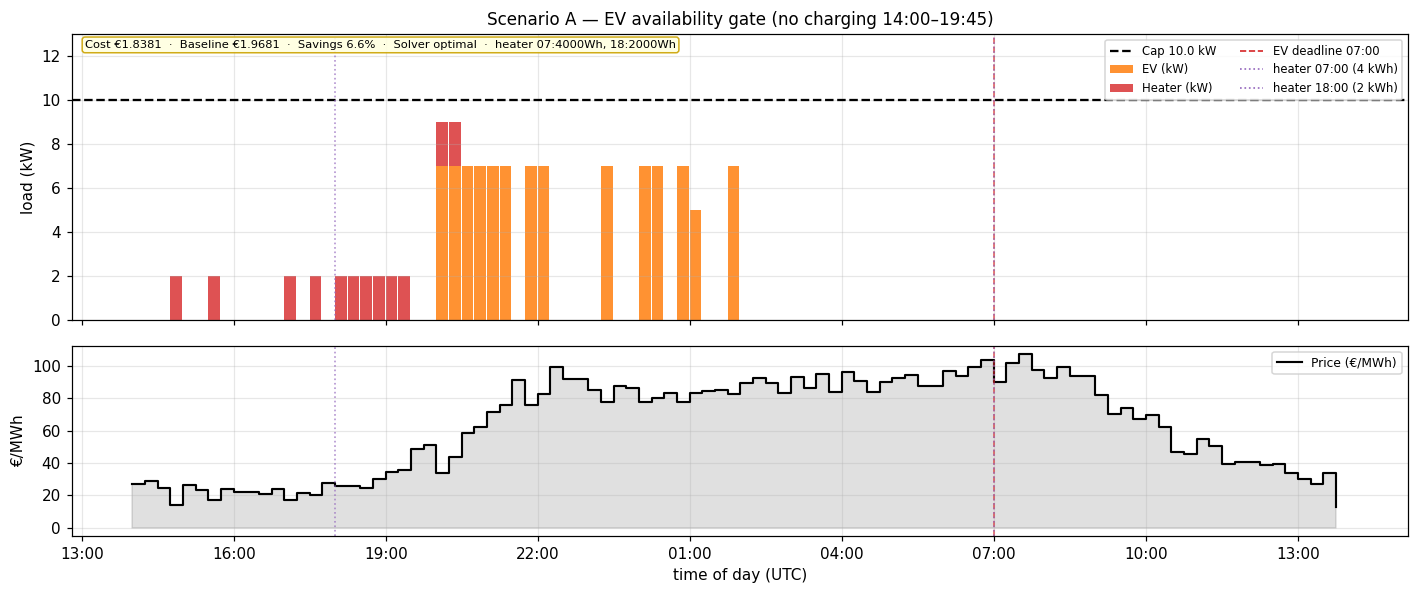

In [2]:
prices_A = make_de_price_curve(seed=1)
now_A = _utc(14)

sched_A = solve_receding_horizon(
    now_A, prices_A, horizon_slots=96, remaining_ev_kwh=24.0,
)

ev = np.asarray(sched_A.ev_power_kw)
print(f"EV [14:00–20:00] kWh = {ev[:24].sum() * SLOT_H:.3f}  (must be 0)")
print(f"EV [20:00–07:00] kWh = {ev[24:68].sum() * SLOT_H:.3f}  (full need)")
print(f"EV [07:00–14:00] kWh = {ev[68:].sum() * SLOT_H:.3f}  (must be 0)")
print(f"Heater windows  kWh = {sched_A.heater_window_kwh}")

assert ev[:24].sum() < 1e-6
assert ev[68:].sum() < 1e-6
assert abs(ev.sum() * SLOT_H - 24.0) < 1e-3

fig_A = plot_schedule(
    sched_A, prices_A,
    title="Scenario A — EV availability gate (no charging 14:00–19:45)",
)
plt.show()


## Scenario B — EV deadline inside vs. outside horizon

Two configurations of the EV deadline against an 8-slot (2 h) horizon:

* **B-near**: now = 05:00, deadline 07:00 (inside the 2 h horizon, slot 8) → C2 hard regime.
* **B-far**: now = 22:00, deadline 07:00 (9 h, well outside the 2 h horizon) → C2 prorated regime with a `deadline_safety = 1.2` margin.

Constraint C2 switches between

> `Δt · Σ_{t<t_d} p_ev[t] + σ_ev ≥ remaining_ev_kwh` &nbsp;&nbsp;(inside)

> `Δt · Σ_t p_ev[t] + σ_ev ≥ remaining_ev_kwh · (H/τ) · γ` &nbsp;&nbsp;(outside).


B-near delivered: 5.000 kWh  (full 5.0 expected)
B-far  delivered: 6.400 kWh  (proportional 24·(2/9)·1.2 ≈ 6.400)


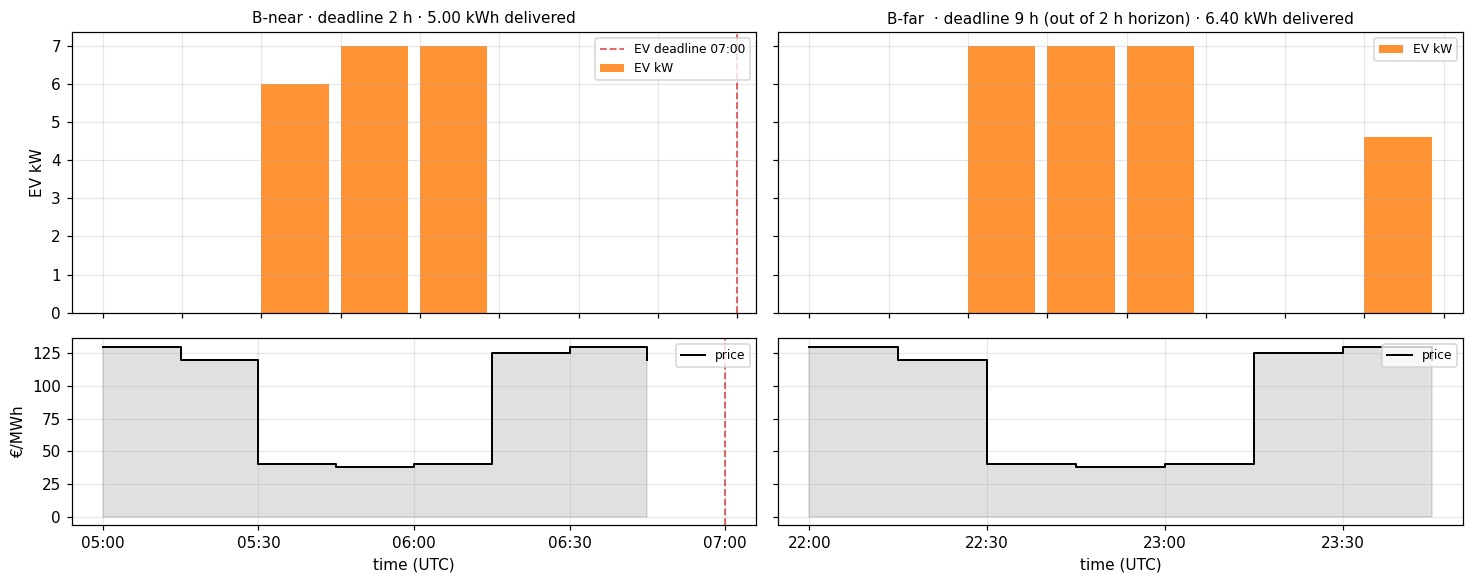

In [3]:
prices_B = np.array([130., 120., 40., 38., 40., 125., 130., 120.])

now_B_near = _utc(5, 0)
now_B_far  = _utc(22, 0)

sched_B_near = solve_receding_horizon(
    now_B_near, prices_B,
    remaining_ev_kwh=5.0, time_to_deadline_h=2.0, horizon_slots=8,
)
sched_B_far = solve_receding_horizon(
    now_B_far, prices_B,
    remaining_ev_kwh=24.0, time_to_deadline_h=9.0, horizon_slots=8,
)

near_kwh = sum(sched_B_near.ev_power_kw) * SLOT_H
far_kwh = sum(sched_B_far.ev_power_kw) * SLOT_H

print(f"B-near delivered: {near_kwh:.3f} kWh  (full 5.0 expected)")
print(f"B-far  delivered: {far_kwh:.3f} kWh  (proportional 24·(2/9)·1.2 ≈ {24*(2/9)*1.2:.3f})")

# Two stacked panels per case: EV power (top) + price (bottom), all datetime.
fig_B, axes = plt.subplots(
    2, 2, figsize=(13.5, 5.4), sharey="row",
    gridspec_kw={"height_ratios": [3, 2]},
)
width_days = SLOT_MINUTES * 0.85 / (60.0 * 24.0)

for col, (now_b, sched_b, kwh_b, label) in enumerate([
    (now_B_near, sched_B_near, near_kwh,
     f"B-near · deadline 2 h · {near_kwh:.2f} kWh delivered"),
    (now_B_far,  sched_B_far,  far_kwh,
     f"B-far  · deadline 9 h (out of 2 h horizon) · {far_kwh:.2f} kWh delivered"),
]):
    ax_p = axes[0, col]
    ax_pr = axes[1, col]
    times = [now_b + timedelta(minutes=SLOT_MINUTES * i) for i in range(8)]
    ax_p.bar(times, sched_b.ev_power_kw, width=width_days,
             color=_PALETTE["ev_charger"], align="edge", alpha=0.85, label="EV kW")
    ax_p.set_title(label, fontsize=10)
    ax_pr.step(times, prices_B, where="post", color="k", lw=1.3, label="price")
    ax_pr.fill_between(times, prices_B, step="post", alpha=0.12, color="k")
    ax_pr.set_xlabel("time (UTC)")
    # Deadline lines (EV only matters here).
    t_end = times[-1] + timedelta(minutes=SLOT_MINUTES)
    for t, lbl, color, ls in _deadline_lines_in(now_b, t_end,
                                                heater_deadlines=()):
        for ax in (ax_p, ax_pr):
            ax.axvline(t, color=color, ls=ls, lw=1.2, alpha=0.75, label=lbl if ax is ax_p else None)
    ax_p.legend(fontsize=8, loc="upper right")
    ax_pr.legend(fontsize=8, loc="upper right")
    ax_pr.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
    ax_pr.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

axes[0, 0].set_ylabel("EV kW")
axes[1, 0].set_ylabel("€/MWh")
fig_B.autofmt_xdate(rotation=0, ha="center")
plt.tight_layout()
plt.show()


## Scenario C — Heater per-window energy delivery

With `HEATER_DEADLINES = (07:00 → 4 kWh, 18:00 → 2 kWh)` over a flat-price
24 h horizon starting at midnight, both windows lie inside the horizon and
must be fully satisfied. The optimiser is free to spread power however it
likes inside each window — the LP only cares about the integral.

We verify the per-window kWh, then plot the full 24 h schedule.


Window 07:00 delivered: 4.000 kWh  (need 4.0)
Window 18:00 delivered: 2.000 kWh  (need 2.0)


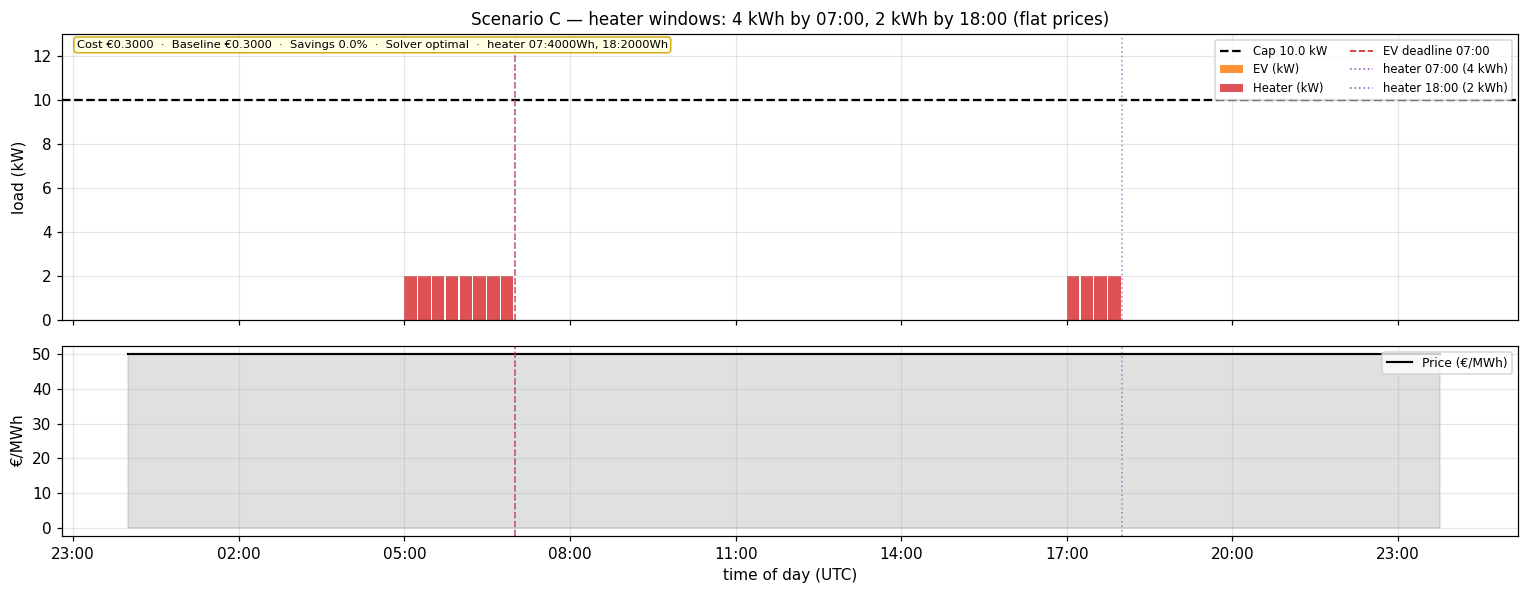

In [4]:
sched_C = solve_receding_horizon(
    _utc(0), np.full(96, 50.0),
    horizon_slots=96, remaining_ev_kwh=0.0,
)

print(f"Window 07:00 delivered: {sched_C.heater_window_kwh[7]:.3f} kWh  (need 4.0)")
print(f"Window 18:00 delivered: {sched_C.heater_window_kwh[18]:.3f} kWh  (need 2.0)")

assert abs(sched_C.heater_window_kwh[7] - 4.0) < 1e-3
assert abs(sched_C.heater_window_kwh[18] - 2.0) < 1e-3

fig_C = plot_schedule(
    sched_C, np.full(96, 50.0),
    title="Scenario C — heater windows: 4 kWh by 07:00, 2 kWh by 18:00 (flat prices)",
    figsize=(14, 5.5),
)
plt.show()


## Scenario D — Heater shapes itself into cheap hours

Same setup as C, but with a price valley between **23:00 and 02:00** (slots
92–95 plus 0–7). The 4 kWh overnight window covers 18:00 → 07:00, so the
heater has 13 h to spend its 4 kWh. The optimiser should concentrate
delivery into the cheap valley.

The daytime 2 kWh window (07:00 → 18:00) has no valley, so we expect
roughly flat delivery there.


Overnight valley kWh / total kWh = 4.000 / 4.000


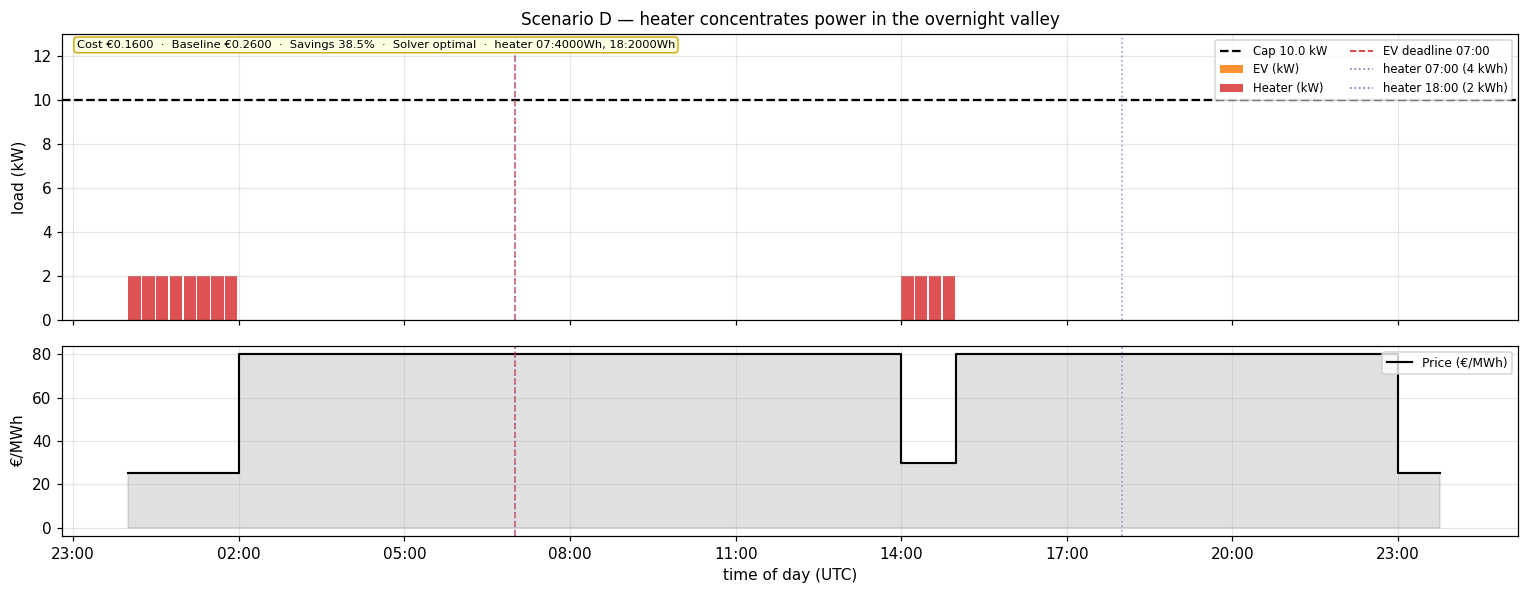

In [5]:
prices_D = np.full(96, 80.0)
prices_D[0:8] = 25.0     # 00:00–02:00 cheap
prices_D[92:96] = 25.0   # 23:00–24:00 cheap
prices_D[56:60] = 30.0   # mid-afternoon (14:00–15:00) cheap

sched_D = solve_receding_horizon(
    _utc(0), prices_D,
    horizon_slots=96, remaining_ev_kwh=0.0,
)

heat = np.asarray(sched_D.heater_power_kw)
overnight_cheap_kwh = (heat[0:8].sum() + heat[92:96].sum()) * SLOT_H
overnight_total_kwh = sched_D.heater_window_kwh[7]
print(f"Overnight valley kWh / total kWh = {overnight_cheap_kwh:.3f} / {overnight_total_kwh:.3f}")

fig_D = plot_schedule(
    sched_D, prices_D,
    title="Scenario D — heater concentrates power in the overnight valley",
    figsize=(14, 5.5),
)
plt.show()


## Scenario E — Power-cap couples EV and heater

Tight cap of **8 kW**: EV (rated 7 kW) plus heater (rated 2 kW) cannot run
flat-out together. We start at 21:00 (inside the EV window), give the EV
12 kWh remaining and the heater its overnight 4 kWh, then watch what the
LP picks during the 21:00–22:00 hour where prices are lowest.


max(EV+heater) = 8.000 kW  (cap 8.0)
EV total kWh    = 12.000
Heater total kWh= 6.000  by window: {7: 4.0, 18: 2.0}


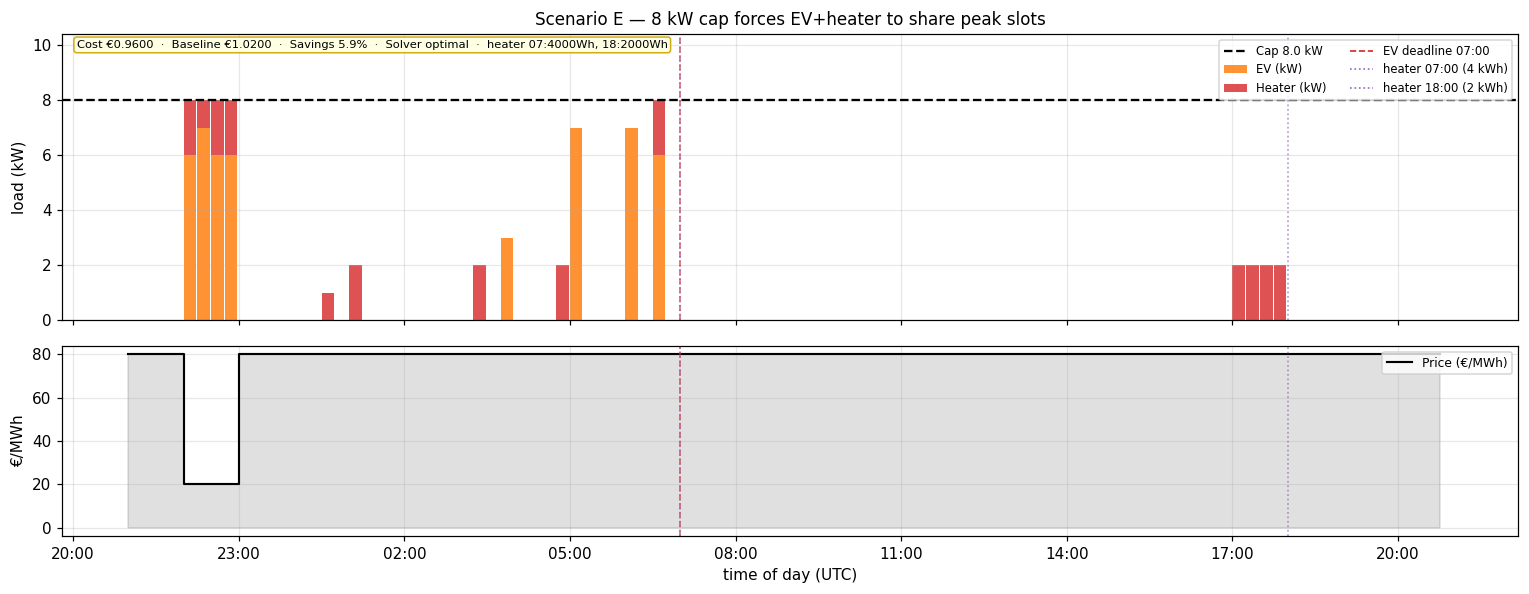

In [6]:
prices_E = np.full(96, 80.0)
prices_E[4:8] = 20.0   # cheapest slot for the start at 21:00 (slots 0..3 = 21:00..22:00, slots 4..7 = 22:00..23:00)

sched_E = solve_receding_horizon(
    _utc(21), prices_E,
    horizon_slots=96, remaining_ev_kwh=12.0, house_cap_kw=8.0,
)

ev = np.asarray(sched_E.ev_power_kw)
heat = np.asarray(sched_E.heater_power_kw)
total = ev + heat
print(f"max(EV+heater) = {total.max():.3f} kW  (cap 8.0)")
assert total.max() <= 8.0 + 1e-6
print(f"EV total kWh    = {ev.sum() * SLOT_H:.3f}")
print(f"Heater total kWh= {heat.sum() * SLOT_H:.3f}  by window: {sched_E.heater_window_kwh}")

fig_E = plot_schedule(
    sched_E, prices_E, cap_kw=8.0,
    title="Scenario E — 8 kW cap forces EV+heater to share peak slots",
    figsize=(14, 5.5),
)
plt.show()


## Scenario F — Committed dishwasher cycle as exogenous load

A dishwasher cycle is already running (committed via the HITL reschedule
flow earlier). It occupies slots 0–7 at 2.5 kW. The cap is **8.5 kW** so
during those 8 slots EV+heater have only `8.5 − 2.5 = 6.0 kW` headroom.

We expect the optimiser to throttle EV+heater accordingly during slots 0–7
and run them freely afterwards.


max load with committed dishwasher = 8.500 kW  (cap 8.5)


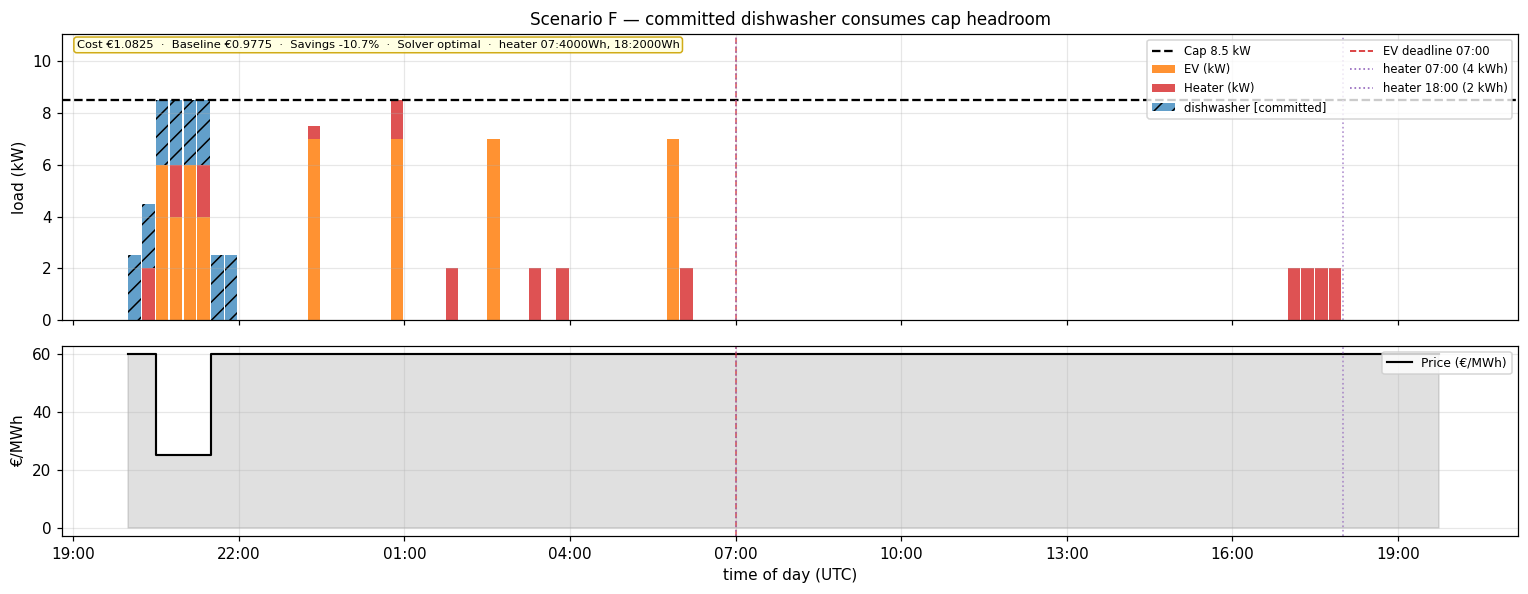

In [7]:
prices_F = np.full(96, 60.0)
prices_F[2:6] = 25.0   # cheapest hour right around the committed cycle

committed_F = [
    ScheduledTask(
        appliance="dishwasher", start_slot=0, slots=8,
        expected_kwh=APPLIANCES["dishwasher"].rated_kw * 8 * SLOT_H,
        committed=True,
    )
]

sched_F = solve_receding_horizon(
    _utc(20), prices_F,
    horizon_slots=96, remaining_ev_kwh=12.0, committed_tasks=committed_F,
    house_cap_kw=8.5,
)

ev = np.asarray(sched_F.ev_power_kw)
heat = np.asarray(sched_F.heater_power_kw)
dish_kw = APPLIANCES["dishwasher"].rated_kw
total_with_dish = ev + heat + np.array(
    [dish_kw if t < 8 else 0.0 for t in range(96)]
)
print(f"max load with committed dishwasher = {total_with_dish.max():.3f} kW  (cap 8.5)")
assert total_with_dish.max() <= 8.5 + 1e-6

fig_F = plot_schedule(
    sched_F, prices_F, cap_kw=8.5,
    title="Scenario F — committed dishwasher consumes cap headroom",
    figsize=(14, 5.5),
)
plt.show()


## Scenario I — HITL throughput stress test

We slam the system with **8 onsets in a 2-hour window** (alternating
dishwasher and washing machine) and run each through the propose →
decide_reschedule → simulated-user pipeline. The HITL gate's *AUTO*
decisions short-circuit small savings, so only the proposals that genuinely
matter make it past the threshold.

The summary table records: per-onset shift, savings, threshold filter,
HITL decision (`ask`/`auto`), and the simulated user's reply.


,appliance,onset,best_shift_min,cost_now_€,cost_best_€,savings_€,above_threshold,decision,sim_user
0,dishwasher,18:00,120.0,0.4376,0.3041,0.1335,True,ask,accept
1,washing_machine,18:30,120.0,0.3076,0.1959,0.1117,True,ask,decline
2,dishwasher,19:00,120.0,0.3948,0.2062,0.1886,True,ask,accept
3,washing_machine,19:15,120.0,0.2799,0.1443,0.1356,True,ask,decline
4,dishwasher,19:45,120.0,0.3226,0.1659,0.1567,True,ask,accept
5,washing_machine,20:00,120.0,0.2425,0.1236,0.1188,True,ask,decline
6,dishwasher,20:30,120.0,0.2530,0.1315,0.1215,True,ask,accept
7,washing_machine,20:45,105.0,0.1833,0.0981,0.0852,False,auto,decline


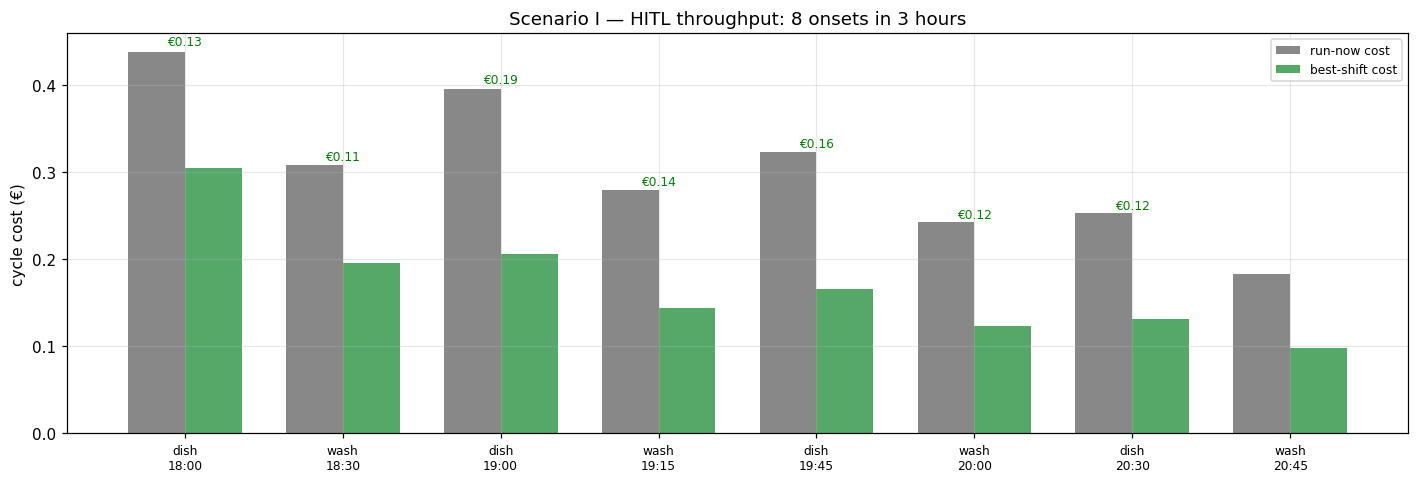


Total potential savings: €1.0516
Of which forwarded to HITL (≥ threshold): €0.9664
Realised savings (sim user accepts dishwasher, declines washer): €0.6003


In [8]:
import itertools
prices_I = make_de_price_curve(seed=3, peak1_h=8.0, peak2_h=19.0)

onsets_I = []
for k, (h, m) in enumerate(
    [(18, 0), (18, 30), (19, 0), (19, 15), (19, 45), (20, 0), (20, 30), (20, 45)]
):
    appliance = "dishwasher" if k % 2 == 0 else "washing_machine"
    onsets_I.append((appliance, _utc(h, m)))

rows = []
for app, onset_at in onsets_I:
    slot_idx = (onset_at.hour * 4 + onset_at.minute // 15)
    slice_p = np.concatenate([prices_I[slot_idx:], prices_I[:slot_idx]])
    spec = APPLIANCES[app]
    p = _propose_for_onset(
        app, onset_at, slice_p,
        cycle_slots=spec.cycle_slots, rated_kw=spec.rated_kw, horizon_slots=96,
    )
    decision = decide_reschedule(p)
    sim_answer = HITL_AUTO_RESPONSES[app]
    rows.append({
        "appliance": app,
        "onset": onset_at.strftime("%H:%M"),
        "best_shift_min": round(p.shift_minutes, 0),
        "cost_now_€": round(p.cost_now_eur, 4),
        "cost_best_€": round(p.cost_proposed_eur, 4),
        "savings_€": round(p.savings_eur, 4),
        "above_threshold": p.savings_eur >= HITL_RESCHEDULE_MIN_SAVINGS_EUR,
        "decision": decision.action,
        "sim_user": sim_answer,
    })

df_I = pd.DataFrame(rows)
display(df_I)

# Plot cost-now vs cost-best per onset.
fig_I, ax = plt.subplots(figsize=(13, 4.5))
x = np.arange(len(df_I))
ax.bar(x - 0.18, df_I["cost_now_€"], width=0.36, color="#888", label="run-now cost")
ax.bar(x + 0.18, df_I["cost_best_€"], width=0.36, color="#55a868", label="best-shift cost")
for i, row in df_I.iterrows():
    if row["above_threshold"]:
        ax.text(i, max(row["cost_now_€"], row["cost_best_€"]) * 1.02,
                f"€{row['savings_€']:.2f}", ha="center", fontsize=8, color="green")
ax.set_xticks(x)
ax.set_xticklabels([f"{r['appliance'][:4]}\n{r['onset']}" for _, r in df_I.iterrows()], fontsize=8)
ax.set_ylabel("cycle cost (€)")
ax.set_title("Scenario I — HITL throughput: 8 onsets in 3 hours")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nTotal potential savings: €{df_I['savings_€'].sum():.4f}")
ask_total = df_I[df_I['decision'] == 'ask']['savings_€'].sum()
print(f"Of which forwarded to HITL (≥ threshold): €{ask_total:.4f}")
print(f"Realised savings (sim user accepts dishwasher, declines washer): "
      f"€{df_I[(df_I['sim_user']=='accept')&(df_I['decision']=='ask')]['savings_€'].sum():.4f}")


## Scenario J — Horizon sensitivity

We solve the same 24 h day with horizons of **6 h, 12 h, and 24 h**, all
evaluated at midnight. A short horizon cannot see the next deadline far
ahead, so it relies on the proportional-EV and proportional-heater
fallbacks; a long horizon sees both deadlines and can plan globally.

We report:
- expected cost
- baseline cost
- savings %
- LP wall-clock time

The 24 h LP should be only a few times slower than the 6 h LP because the
problem has no integer variables.

> **Note — forecast costs, not realized costs.**  
> `expected_cost_€` and `baseline_cost_€` are both computed from the *same
> price forecast* passed to the solver; neither reflects what the household
> actually paid. `expected_cost_€` is what the LP-optimal schedule would
> cost if the forecast were perfect; `baseline_cost_€` is what a naive
> price-unaware (run-as-soon-as-possible) schedule would cost under the
> same forecast. The comparison is apples-to-apples between two *plans*,
> not between a plan and an outcome.  
> Realized slot-by-slot costs (based only on loads that physically ran,
> billed at the actual market price) are shown in notebook **06 — End-to-end
> simulation** via `cum_cost_eur`.

,horizon_h,horizon_slots,expected_cost_€,baseline_cost_€,savings_%,ev_total_kWh,heater_kWh_07,heater_kWh_18,solve_ms,status
0,6,24,0.5396,0.6042,10.7,24.686,4.0,0.0,11.8,optimal
1,12,48,0.6665,0.7526,11.4,24.000,4.0,2.0,20.5,optimal
2,24,96,0.6665,0.7526,11.4,24.000,4.0,2.0,37.6,optimal


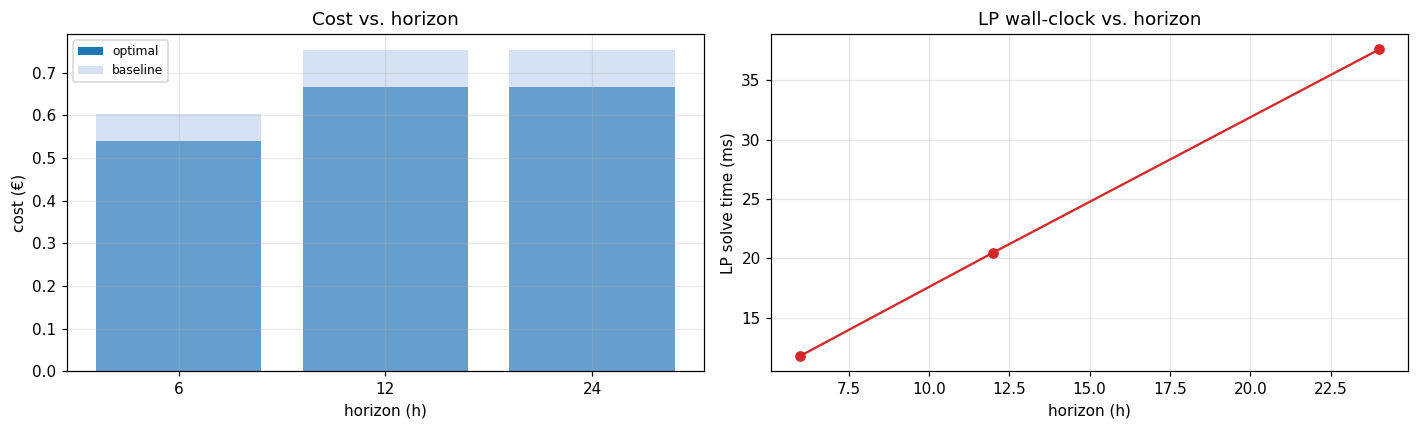

In [9]:
prices_J = make_de_price_curve(seed=4)

results = []
for h in (6, 12, 24):
    slots = h * 4
    p_slice = prices_J[:slots]
    t0 = time.perf_counter()
    s = solve_receding_horizon(
        _utc(0), p_slice, horizon_slots=slots, remaining_ev_kwh=24.0,
    )
    dt_ms = (time.perf_counter() - t0) * 1000.0
    results.append({
        "horizon_h": h,
        "horizon_slots": slots,
        "expected_cost_€": round(s.expected_cost, 4),
        "baseline_cost_€": round(s.baseline_cost, 4),
        "savings_%": round(s.savings() * 100, 1),
        "ev_total_kWh": round(sum(s.ev_power_kw) * SLOT_H, 3),
        "heater_kWh_07": round(s.heater_window_kwh.get(7, 0.0), 3),
        "heater_kWh_18": round(s.heater_window_kwh.get(18, 0.0), 3),
        "solve_ms": round(dt_ms, 1),
        "status": s.solver_status,
    })
df_J = pd.DataFrame(results)
display(df_J)

fig_J, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(df_J["horizon_h"].astype(str), df_J["expected_cost_€"],
            color="#1f77b4", label="optimal")
axes[0].bar(df_J["horizon_h"].astype(str), df_J["baseline_cost_€"],
            color="#aec7e8", alpha=0.5, label="baseline")
axes[0].set_xlabel("horizon (h)")
axes[0].set_ylabel("cost (€)")
axes[0].set_title("Cost vs. horizon")
axes[0].legend(fontsize=8)
axes[1].plot(df_J["horizon_h"], df_J["solve_ms"], "o-", color="#d62728")
axes[1].set_xlabel("horizon (h)")
axes[1].set_ylabel("LP solve time (ms)")
axes[1].set_title("LP wall-clock vs. horizon")
plt.tight_layout()
plt.show()


## Scenario K — Heater infeasibility → soft slack

We override `HEATER_DEADLINES` with a deliberately impossible spec:
**100 kWh required by 07:00**. The heater rated power is 2 kW so the
maximum it can deliver in any 13 h overnight window is 26 kWh — slack must
absorb the rest. The LP must remain feasible (`status="optimal"`) because
the slack penalty is dominated only by the cost we *cannot* shave.


Heater max power across horizon: 2.000 kW  (rated 2.0)
Window 07:00 delivered: 14.000 kWh  (asked 100; physical max ≤ 26)
Solver status: optimal


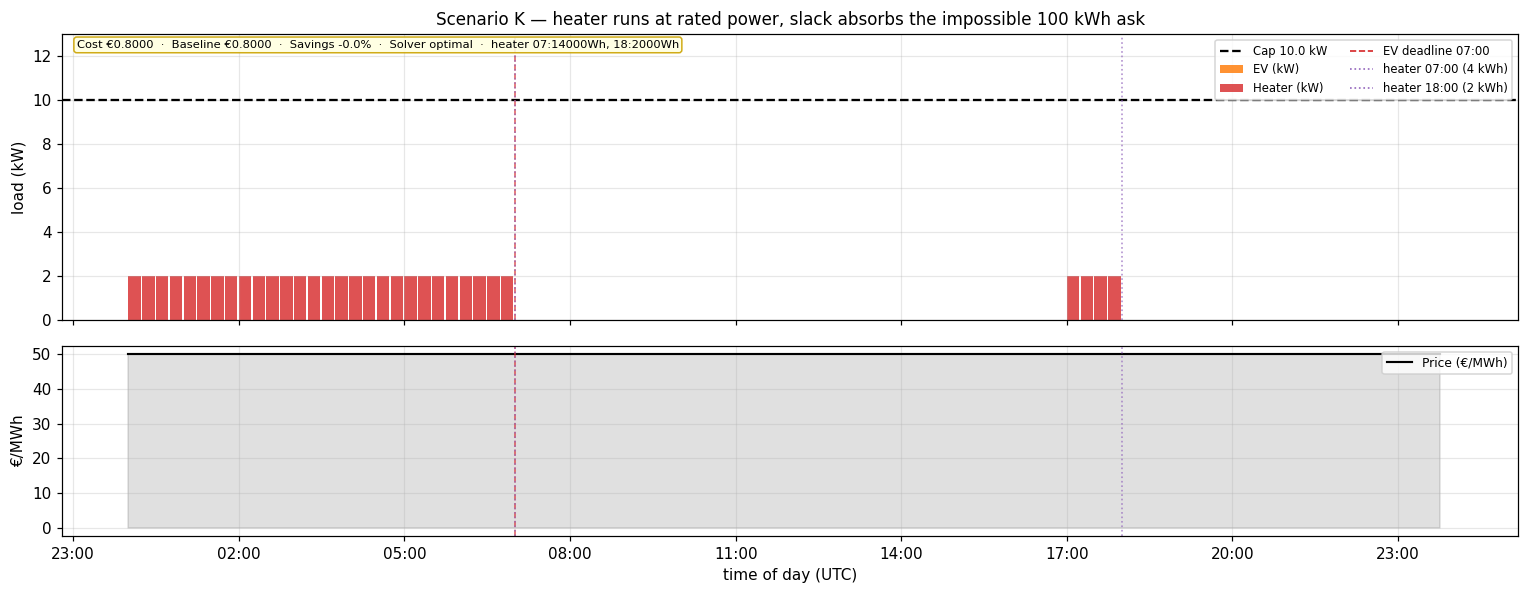

In [10]:
custom = (
    HeaterEnergyDeadline(hour=7, kwh_required=100.0),
    HeaterEnergyDeadline(hour=18, kwh_required=2.0),
)
prices_K = np.full(96, 50.0)

sched_K = solve_receding_horizon(
    _utc(0), prices_K,
    horizon_slots=96, remaining_ev_kwh=0.0,
    heater_deadlines=custom,
)
heat = np.asarray(sched_K.heater_power_kw)
print(f"Heater max power across horizon: {heat.max():.3f} kW  (rated 2.0)")
print(f"Window 07:00 delivered: {sched_K.heater_window_kwh[7]:.3f} kWh  (asked 100; physical max ≤ 26)")
print(f"Solver status: {sched_K.solver_status}")
assert sched_K.solver_status in ("optimal", "optimal_inaccurate")

fig_K = plot_schedule(
    sched_K, prices_K,
    title="Scenario K — heater runs at rated power, slack absorbs the impossible 100 kWh ask",
    figsize=(14, 5.5),
)
plt.show()


## Scenario L — Joint MIP vs price-only reschedule (cap binding)

This scenario shows *why* the optimiser solves the reschedule jointly with
the EV / heater plan instead of using a price-only shift score.

The setup is constructed so the cap binds and the trade-off is visible:

* **Now = 04:30 UTC**, EV needs **14 kWh** by **07:00** (the next 2.5 h).
* **House cap = 7.5 kW** — EV (7 kW) + dishwasher (2.5 kW) = 9.5 kW > cap,
  so any overlap forces EV down to **5 kW** while the cycle runs.
* Prices: **€200/MWh** for the next hour (04:30 → 05:30), then a deep
  **€10/MWh** valley for exactly 2 hours (05:30 → 07:30), then **€50/MWh**.
* The 2-hour cheap valley is tuned to be *exactly* the EV's full-rate
  charging time (14 kWh / 7 kW = 2 h) — every kWh the EV misses there
  must come from the €200 hour, which is 20× more expensive.
* The user starts the **dishwasher at 04:30** (8-slot, 2-hour cycle).

The price-only logic (`_propose_for_onset`) sees the cheapest 8-slot start
and recommends shifting the cycle straight into the valley — that's the
local optimum *for the cycle alone*. But planting the cycle there forces
the EV to share the cap during its only cheap window, pushing 4 kWh of EV
charging into the €200 hour.

The joint MIP (the new `solve_receding_horizon` with `pending_cycles=[…]`)
co-optimises the cycle placement with the EV / heater plan and the cap. It
shifts the cycle to **after** the cheap window instead, so the EV gets the
full valley uninterrupted — at the price of the cycle finishing in the
€50/MWh medium tier.

The plan-level cost gap is **~30%** in favour of the joint MIP.


──────────────────────────────────────────────────────────────
Price-only naive shift          : slot 4 (+1.00 h)
  isolated cycle cost           : €0.0500   ← what the user is told
  plan-level cost if committed  : €1.4250   ← what the user actually pays

Joint MIP optimal shift         : slot 8 (+2.00 h)
  plan-level cost               : €1.1450   ← lower

Δ = €+0.2800  (+19.6% relative)
──────────────────────────────────────────────────────────────


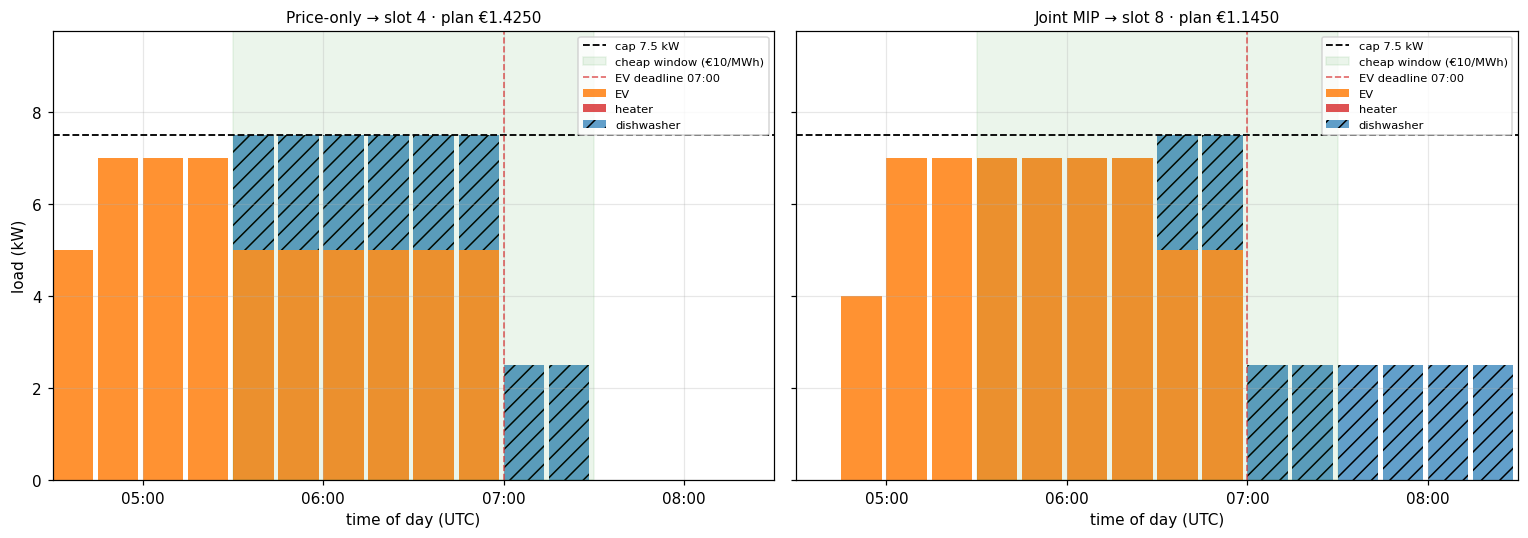

In [11]:
# Setup: tight cap (7.5 kW) so EV (7 kW) + dish (2.5 kW) cannot co-run at
# rated power, and a 2 h cheap window (slots 4-11) sized exactly to the
# EV's 14 kWh / 7 kW = 2 h need. Any kWh the EV loses inside the cheap
# window must come from the €200 hour right before — a 20× price gap.
# Heater is disabled (heater_deadlines=()) to isolate the EV-vs-cycle
# trade-off; with a heater also competing for the same cheap slots the
# constraint interaction would muddy the comparison.
prices_L = np.full(96, 60.0)
prices_L[0:4]   = 200.0     # 04:30–05:30 very expensive (1 h)
prices_L[4:12]  = 10.0      # 05:30–07:30 deeply cheap (2 h, exactly the EV's need)
prices_L[12:16] = 50.0      # 07:30–08:30 medium

now_L = _utc(4, 30)
EV_NEED_KWH = 14.0
TIME_TO_DEADLINE_H = 2.5    # EV deadline at 07:00, slot 10
CAP_KW = 7.5

spec = APPLIANCES["dishwasher"]
window_slots = int(HITL_RESCHEDULE_WINDOW_HOURS * 60.0 / SLOT_MINUTES)
last_start = min(window_slots, 96 - spec.cycle_slots)

# (1) Price-only proposal — the legacy shift score we used pre-MIP. It
#     ignores EV / heater / cap, so it just finds the cheapest 8 slots.
slice_L = prices_L[:96]
naive = _propose_for_onset(
    "dishwasher", now_L, slice_L,
    cycle_slots=spec.cycle_slots, rated_kw=spec.rated_kw, horizon_slots=96,
)

# (2) Joint MIP — schedule with a pending dishwasher and tight EV deadline.
def _solve_with_cycle_at(slot: int):
    return solve_receding_horizon(
        now_L, prices_L, horizon_slots=96,
        remaining_ev_kwh=EV_NEED_KWH, time_to_deadline_h=TIME_TO_DEADLINE_H,
        house_cap_kw=CAP_KW, heater_deadlines=(),
        pending_cycles=[PendingCycle(
            appliance="dishwasher", cycle_slots=spec.cycle_slots,
            rated_kw=spec.rated_kw,
            earliest_start_slot=slot, latest_start_slot=slot,
        )],
    )

sched_joint = solve_receding_horizon(
    now_L, prices_L, horizon_slots=96,
    remaining_ev_kwh=EV_NEED_KWH, time_to_deadline_h=TIME_TO_DEADLINE_H,
    house_cap_kw=CAP_KW, heater_deadlines=(),
    pending_cycles=[PendingCycle(
        appliance="dishwasher", cycle_slots=spec.cycle_slots,
        rated_kw=spec.rated_kw, earliest_start_slot=0,
        latest_start_slot=last_start,
    )],
)
joint_slot = sched_joint.cycle_starts["dishwasher"]
joint_cost = sched_joint.expected_cost

# (3) Plan-level cost the user would actually realise if the price-only
#     logic decided — pin the cycle at the naive slot and re-solve under
#     the same EV / cap constraints.
naive_slot = int(round((naive.proposed_start_at - now_L).total_seconds() / 60.0 / SLOT_MINUTES))
sched_pin_naive = _solve_with_cycle_at(naive_slot)
naive_realised_cost = sched_pin_naive.expected_cost

print("─" * 62)
print(f"Price-only naive shift          : slot {naive_slot} (+{naive_slot*SLOT_H:.2f} h)")
print(f"  isolated cycle cost           : €{naive.cost_proposed_eur:.4f}   ← what the user is told")
print(f"  plan-level cost if committed  : €{naive_realised_cost:.4f}   ← what the user actually pays")
print()
print(f"Joint MIP optimal shift         : slot {joint_slot} (+{joint_slot*SLOT_H:.2f} h)")
print(f"  plan-level cost               : €{joint_cost:.4f}   ← lower")
print()
delta = naive_realised_cost - joint_cost
pct = (1 - joint_cost / max(naive_realised_cost, 1e-9)) * 100
print(f"Δ = €{delta:+.4f}  ({pct:+.1f}% relative)")
print("─" * 62)

# Side-by-side stack plots on a datetime axis, zoomed on the first 4 h.
fig_L, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
width_days = SLOT_MINUTES * 0.9 / (60.0 * 24.0)
zoom_end = now_L + timedelta(hours=4)
ev_deadline = now_L + timedelta(hours=TIME_TO_DEADLINE_H)
for ax, sched, slot, title in [
    (axes[0], sched_pin_naive, naive_slot,
     f"Price-only → slot {naive_slot} · plan €{naive_realised_cost:.4f}"),
    (axes[1], sched_joint, joint_slot,
     f"Joint MIP → slot {joint_slot} · plan €{joint_cost:.4f}"),
]:
    T = sched.horizon_slots
    times = [now_L + timedelta(minutes=SLOT_MINUTES * i) for i in range(T)]
    ev = np.asarray(sched.ev_power_kw)
    heat = np.asarray(sched.heater_power_kw)
    dish = np.zeros(T)
    dish[slot : slot + spec.cycle_slots] = spec.rated_kw
    ax.bar(times, ev, width=width_days, color=_PALETTE["ev_charger"],
           label="EV", align="edge", alpha=0.85)
    ax.bar(times, heat, width=width_days, bottom=ev,
           color=_PALETTE["heater"], label="heater", align="edge", alpha=0.8)
    ax.bar(times, dish, width=width_days, bottom=ev + heat,
           color=_PALETTE["dishwasher"], hatch="//", label="dishwasher",
           align="edge", alpha=0.7)
    ax.axhline(CAP_KW, color="black", ls="--", lw=1.2, label=f"cap {CAP_KW} kW")
    cheap_start = now_L + timedelta(minutes=SLOT_MINUTES * 4)
    cheap_end   = now_L + timedelta(minutes=SLOT_MINUTES * 12)
    ax.axvspan(cheap_start, cheap_end, alpha=0.08, color="green",
               label="cheap window (€10/MWh)")
    ax.axvline(ev_deadline, color="#d62728", ls="--", lw=1.1, alpha=0.7,
               label="EV deadline 07:00")
    ax.set_title(title, fontsize=10)
    ax.set_xlim(now_L, zoom_end)
    ax.set_ylim(0, max(CAP_KW * 1.3, 9.5))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.set_xlabel("time of day (UTC)")
    ax.legend(fontsize=7.5, loc="upper right")
axes[0].set_ylabel("load (kW)")
fig_L.autofmt_xdate(rotation=0, ha="center")
plt.tight_layout()
plt.show()


## Scenario M — Re-nudge before start ("postpone for another hour")

This scenario exercises the new behaviour: **any cycle that has not started
yet remains replannable**.

Flow:

1. At 20:00 the user starts the dishwasher. The joint solver proposes a +1 h
   shift (slot 4). We commit that deferred start.
2. Fifteen minutes later (20:15), a *different* appliance onset appears
   (washing machine). We now include:
   - the new onset,
   - the deferred dishwasher as a synthetic replannable onset
     (`CommitTracker.replannable_onsets`),
   and re-solve jointly.
3. The solver nudges dishwasher again to a later slot (another hour-like move)
   while also placing washing machine, all under the same cap.


First plan (20:00):
  dishwasher slot = 4  (+1.00 h)
Second plan (20:15) with new washing-machine onset:
  dishwasher slot = 8  (+2.00 h from now)
  washing machine slot = 0  (+0.00 h from now)
  dishwasher additional nudge = 1.25 h


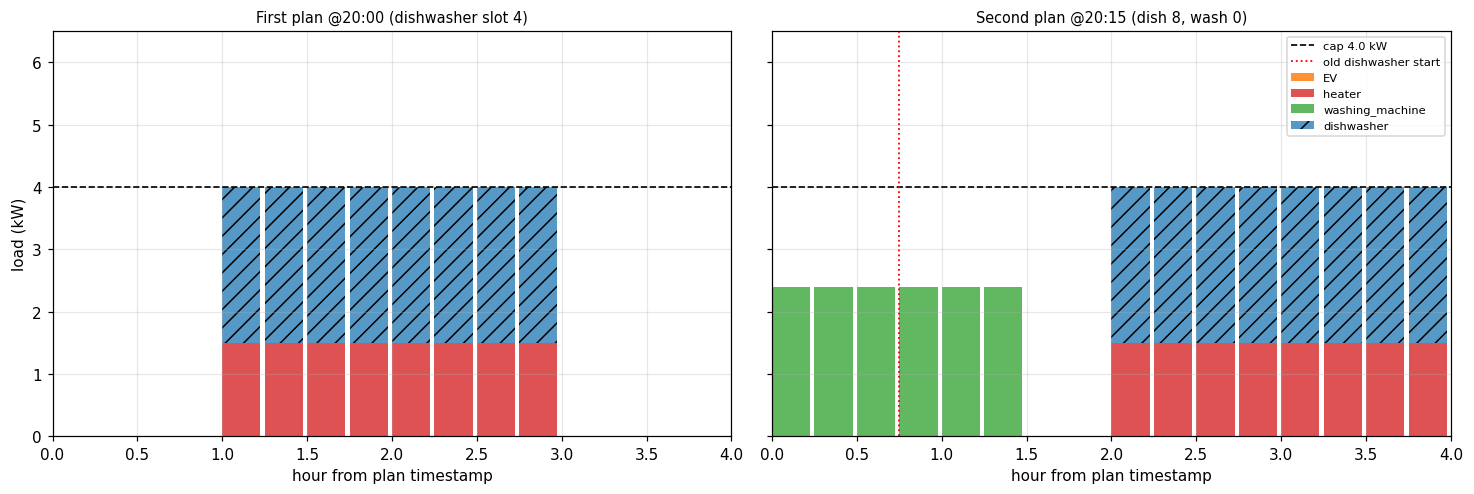

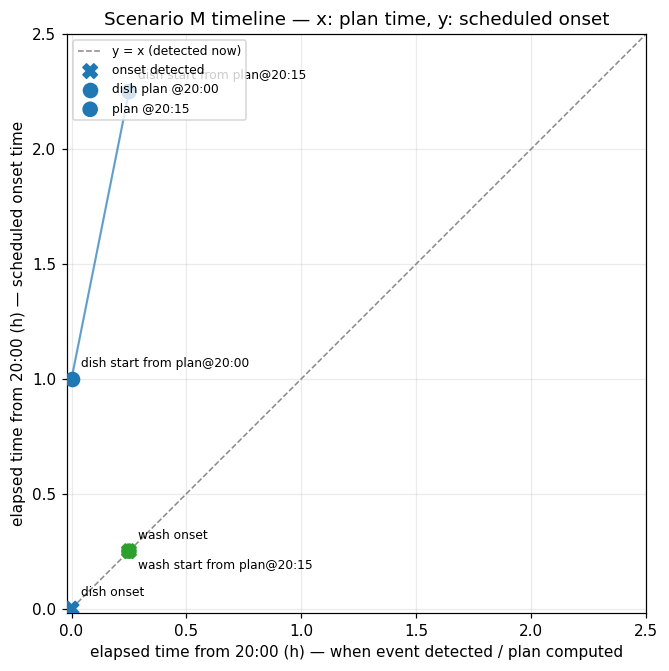

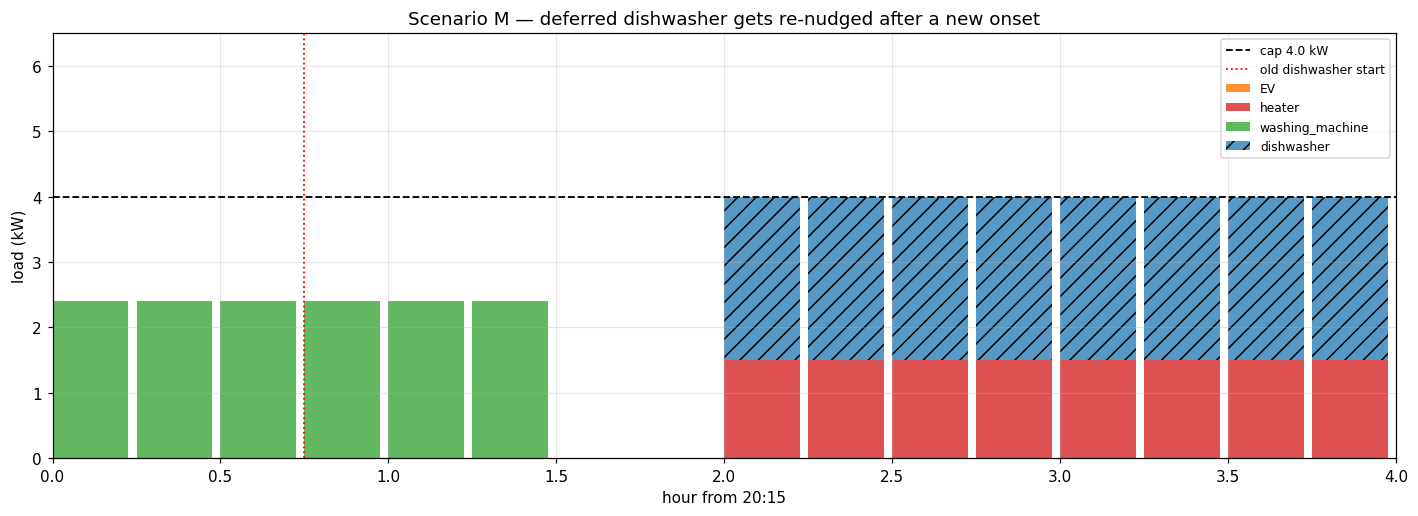

In [12]:
now0 = _utc(20, 0)
spec_d = APPLIANCES["dishwasher"]
spec_w = APPLIANCES["washing_machine"]

# Step 1 — first onset (dishwasher only): best slot is +1 h.
prices_M0 = np.full(96, 80.0)
prices_M0[4:12] = 20.0
sched_M0 = solve_receding_horizon(
    now0, prices_M0,
    horizon_slots=96, remaining_ev_kwh=0.0, house_cap_kw=4.0,
    pending_cycles=[PendingCycle(
        appliance="dishwasher",
        cycle_slots=spec_d.cycle_slots,
        rated_kw=spec_d.rated_kw,
        earliest_start_slot=0, latest_start_slot=8,
    )],
)
first_slot = int(sched_M0.cycle_starts["dishwasher"])

commit = CommitTracker()
cycle_kwh_d = spec_d.rated_kw * spec_d.cycle_slots * SLOT_H
commit.adopt_cycle_start(
    appliance="dishwasher",
    slots=spec_d.cycle_slots,
    expected_kwh=cycle_kwh_d,
    start_at=now0 + timedelta(minutes=SLOT_MINUTES * first_slot),
    now=now0,
)

# Step 2 — 15 min later, another onset appears (washing machine).
now1 = now0 + timedelta(minutes=15)
replannable = commit.replannable_onsets(now1)
assert any(o.appliance == "dishwasher" for o in replannable), "Deferred dishwasher must stay replannable."

prices_M1 = np.full(96, 80.0)
prices_M1[3:8] = 200.0
prices_M1[8:16] = 20.0

sched_M1 = solve_receding_horizon(
    now1, prices_M1,
    horizon_slots=96, remaining_ev_kwh=0.0, house_cap_kw=4.0,
    pending_cycles=[
        PendingCycle(
            appliance="dishwasher",
            cycle_slots=spec_d.cycle_slots,
            rated_kw=spec_d.rated_kw,
            earliest_start_slot=0, latest_start_slot=8,
        ),
        PendingCycle(
            appliance="washing_machine",
            cycle_slots=spec_w.cycle_slots,
            rated_kw=spec_w.rated_kw,
            earliest_start_slot=0, latest_start_slot=8,
        ),
    ],
)

second_slot = int(sched_M1.cycle_starts["dishwasher"])
wm_slot = int(sched_M1.cycle_starts["washing_machine"])

print("First plan (20:00):")
print(f"  dishwasher slot = {first_slot}  (+{first_slot*SLOT_H:.2f} h)")
print("Second plan (20:15) with new washing-machine onset:")
print(f"  dishwasher slot = {second_slot}  (+{second_slot*SLOT_H:.2f} h from now)")
print(f"  washing machine slot = {wm_slot}  (+{wm_slot*SLOT_H:.2f} h from now)")
print(f"  dishwasher additional nudge = {(second_slot - (first_slot-1))*SLOT_H:.2f} h")

# From 20:15, the original +1 h dishwasher start corresponds to slot 3.
orig_slot_from_now1 = first_slot - 1
assert second_slot >= orig_slot_from_now1 + 4, "Expected dishwasher to be nudged by ~another hour."

# Visualise first and second plans side-by-side.
T = sched_M1.horizon_slots
hrs = np.arange(T) * SLOT_H

dish_first = np.zeros(T); dish_first[first_slot:first_slot + spec_d.cycle_slots] = spec_d.rated_kw
dish_second = np.zeros(T); dish_second[second_slot:second_slot + spec_d.cycle_slots] = spec_d.rated_kw
wash_second = np.zeros(T); wash_second[wm_slot:wm_slot + spec_w.cycle_slots] = spec_w.rated_kw

fig_M_plans, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), sharey=True)
for ax, title, ev_arr, heat_arr, dish_arr, wash_arr, mark_old in [
    (
        axes[0],
        f"First plan @20:00 (dishwasher slot {first_slot})",
        np.asarray(sched_M0.ev_power_kw),
        np.asarray(sched_M0.heater_power_kw),
        dish_first,
        np.zeros(T),
        None,
    ),
    (
        axes[1],
        f"Second plan @20:15 (dish {second_slot}, wash {wm_slot})",
        np.asarray(sched_M1.ev_power_kw),
        np.asarray(sched_M1.heater_power_kw),
        dish_second,
        wash_second,
        orig_slot_from_now1 * SLOT_H,
    ),
]:
    ax.bar(hrs, ev_arr, width=SLOT_H*0.9, color=_PALETTE["ev_charger"], alpha=0.85, label="EV", align="edge")
    ax.bar(hrs, heat_arr, width=SLOT_H*0.9, bottom=ev_arr, color=_PALETTE["heater"], alpha=0.8, label="heater", align="edge")
    ax.bar(hrs, wash_arr, width=SLOT_H*0.9, bottom=ev_arr+heat_arr, color=_PALETTE["washing_machine"], alpha=0.75, label="washing_machine", align="edge")
    ax.bar(hrs, dish_arr, width=SLOT_H*0.9, bottom=ev_arr+heat_arr+wash_arr, color=_PALETTE["dishwasher"], hatch="//", alpha=0.75, label="dishwasher", align="edge")
    ax.axhline(4.0, color="black", ls="--", lw=1.1, label="cap 4.0 kW")
    if mark_old is not None:
        ax.axvline(mark_old, color="red", ls=":", lw=1.2, label="old dishwasher start")
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 6.5)
    ax.set_xlabel("hour from plan timestamp")
    ax.set_title(title, fontsize=9.5)
axes[0].set_ylabel("load (kW)")
axes[1].legend(fontsize=7.5, loc="upper right")
plt.tight_layout()
plt.show()

# Timeline view (requested): x = elapsed replan/detection time,
# y = elapsed scheduled start time. Onset detections lie on y=x.
t0 = now0
t_event_dish = now0
t_event_wash = now1
t_plan1_dish = now0 + timedelta(minutes=SLOT_MINUTES * first_slot)
t_plan2_dish = now1 + timedelta(minutes=SLOT_MINUTES * second_slot)
t_plan2_wash = now1 + timedelta(minutes=SLOT_MINUTES * wm_slot)

def _eh(dt):
    return (dt - t0).total_seconds() / 3600.0

fig_M_timeline, ax = plt.subplots(figsize=(8.2, 6.2))

# Reference diagonal y=x: "detected now".
grid_max_h = max(_eh(t_plan2_dish), _eh(t_plan1_dish), _eh(t_plan2_wash), 2.0) + 0.25
ax.plot([0, grid_max_h], [0, grid_max_h], color="#888888", ls="--", lw=1.0, label="y = x (detected now)")

# Onset detections (special marker, on the diagonal).
ax.scatter(
    [_eh(t_event_dish), _eh(t_event_wash)],
    [_eh(t_event_dish), _eh(t_event_wash)],
    color=[_PALETTE["dishwasher"], _PALETTE["washing_machine"]],
    marker="X", s=90, zorder=4, label="onset detected",
)

# Planned starts from replan @20:00 and @20:15.
ax.scatter(
    [_eh(now0)],
    [_eh(t_plan1_dish)],
    color=_PALETTE["dishwasher"], marker="o", s=85, zorder=5, label="dish plan @20:00",
)
ax.scatter(
    [_eh(now1), _eh(now1)],
    [_eh(t_plan2_dish), _eh(t_plan2_wash)],
    color=[_PALETTE["dishwasher"], _PALETTE["washing_machine"]],
    marker="o", s=85, zorder=5, label="plan @20:15",
)

# Connect same-appliance planned points to show re-nudge slope.
ax.plot(
    [_eh(now0), _eh(now1)],
    [_eh(t_plan1_dish), _eh(t_plan2_dish)],
    color=_PALETTE["dishwasher"], alpha=0.7, lw=1.4,
)

ax.annotate("dish onset", (_eh(t_event_dish), _eh(t_event_dish)), xytext=(6, 8), textcoords="offset points", fontsize=8)
ax.annotate("wash onset", (_eh(t_event_wash), _eh(t_event_wash)), xytext=(6, 8), textcoords="offset points", fontsize=8)
ax.annotate("dish start from plan@20:00", (_eh(now0), _eh(t_plan1_dish)), xytext=(6, 8), textcoords="offset points", fontsize=8)
ax.annotate("dish start from plan@20:15", (_eh(now1), _eh(t_plan2_dish)), xytext=(6, 8), textcoords="offset points", fontsize=8)
ax.annotate("wash start from plan@20:15", (_eh(now1), _eh(t_plan2_wash)), xytext=(6, -12), textcoords="offset points", fontsize=8)

ax.set_xlim(-0.02, grid_max_h)
ax.set_ylim(-0.02, grid_max_h)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("elapsed time from 20:00 (h) — when event detected / plan computed")
ax.set_ylabel("elapsed time from 20:00 (h) — scheduled onset time")
ax.set_title("Scenario M timeline — x: plan time, y: scheduled onset")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

# Visualise the second joint plan (detailed stack, same as before).
T = sched_M1.horizon_slots
hrs = np.arange(T) * SLOT_H
ev = np.asarray(sched_M1.ev_power_kw)
heat = np.asarray(sched_M1.heater_power_kw)
dish = np.zeros(T); dish[second_slot:second_slot + spec_d.cycle_slots] = spec_d.rated_kw
wash = np.zeros(T); wash[wm_slot:wm_slot + spec_w.cycle_slots] = spec_w.rated_kw

fig_M, ax = plt.subplots(figsize=(13, 4.8))
ax.bar(hrs, ev, width=SLOT_H*0.9, color=_PALETTE["ev_charger"], alpha=0.85, label="EV", align="edge")
ax.bar(hrs, heat, width=SLOT_H*0.9, bottom=ev, color=_PALETTE["heater"], alpha=0.8, label="heater", align="edge")
ax.bar(hrs, wash, width=SLOT_H*0.9, bottom=ev+heat, color=_PALETTE["washing_machine"], alpha=0.75, label="washing_machine", align="edge")
ax.bar(hrs, dish, width=SLOT_H*0.9, bottom=ev+heat+wash, color=_PALETTE["dishwasher"], hatch="//", alpha=0.75, label="dishwasher", align="edge")
ax.axhline(4.0, color="black", ls="--", lw=1.2, label="cap 4.0 kW")
ax.axvline(orig_slot_from_now1 * SLOT_H, color="red", ls=":", lw=1.2, label="old dishwasher start")
ax.set_xlim(0, 4)
ax.set_ylim(0, 6.5)
ax.set_xlabel("hour from 20:15")
ax.set_ylabel("load (kW)")
ax.set_title("Scenario M — deferred dishwasher gets re-nudged after a new onset")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()


## Scenario N — Home Battery: cheap-overnight charge, expensive-peak discharge

The Home Battery has capacity **13.5 kWh**, max charge/discharge **5 kW**,
and round-trip efficiency **~90%** (η_c = η_d = 0.95).

We construct a 24 h price profile with a cheap overnight trough
(€15/MWh, 01:00–05:00) and an expensive morning peak (€120/MWh, 07:00–10:00)
plus a moderate evening peak (€90/MWh, 17:00–21:00).

The battery should:
1. Charge to capacity during the overnight trough (cheap energy).
2. Discharge during the morning and evening peaks (costly energy).
3. Never let SoC go negative or exceed capacity.

We plot:
- **Top**: charge power (blue), discharge power (orange), and net SoC trajectory
  (green dashed) against the right axis.
- **Bottom**: realized price curve.


Max SoC reached:          2.11 kWh  (capacity 13.5 kWh)
Peak charge rate:         5.00 kW   (max 5.0 kW)
Peak discharge rate:      2.00 kW   (max 5.0 kW)
SoC ever negative:        False
SoC ever > capacity:      False
Charge slots:             2
Discharge slots:          4
Charge slots inside cheap window:    2 / 2
Discharge slots inside peak windows: 4 / 4


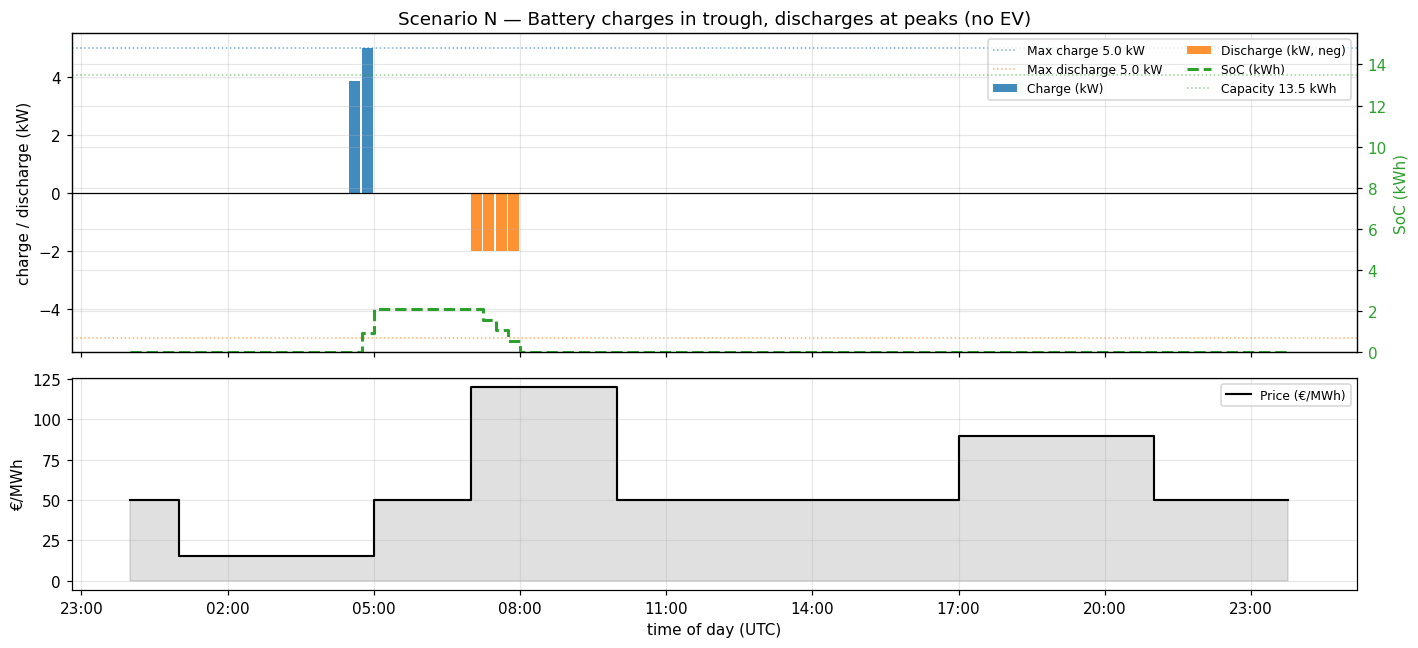

In [13]:
from aerogrid.config import (
    BatterySpec,
    HOME_BATTERY_CAPACITY_KWH,
    HOME_BATTERY_MAX_POWER_KW,
    HOME_BATTERY_ETA_CHARGE,
    HOME_BATTERY_ETA_DISCHARGE,
)

# Construct cheap-overnight / expensive-peak price curve.
prices_N = np.full(96, 50.0)          # base €50/MWh
prices_N[4:20]   = 15.0               # 01:00–05:00 cheap trough
prices_N[28:40]  = 120.0              # 07:00–10:00 morning peak
prices_N[68:84]  = 90.0              # 17:00–21:00 evening peak

now_N = _utc(0)
bspec = BatterySpec()

sched_N = solve_receding_horizon(
    now_N, prices_N,
    horizon_slots=96,
    remaining_ev_kwh=0.0,
    battery_spec=bspec,
    initial_soc_kwh=0.0,
)

chg = np.asarray(sched_N.battery_charge_kw, dtype=float)
dis = np.asarray(sched_N.battery_discharge_kw, dtype=float)
soc = np.asarray(sched_N.soc_kwh, dtype=float)

print(f"Max SoC reached:          {soc.max():.2f} kWh  (capacity {bspec.capacity_kwh} kWh)")
print(f"Peak charge rate:         {chg.max():.2f} kW   (max {bspec.max_charge_kw} kW)")
print(f"Peak discharge rate:      {dis.max():.2f} kW   (max {bspec.max_discharge_kw} kW)")
print(f"SoC ever negative:        {(soc < -1e-6).any()}")
print(f"SoC ever > capacity:      {(soc > bspec.capacity_kwh + 1e-6).any()}")
print(f"Charge slots:             {(chg > 0.01).sum()}")
print(f"Discharge slots:          {(dis > 0.01).sum()}")

# Verify charge happens in cheap window, discharge in peaks.
cheap_slots  = set(range(4, 20))
peak_slots   = set(range(28, 40)) | set(range(68, 84))
chg_slots    = set(np.where(chg > 0.01)[0])
dis_slots    = set(np.where(dis > 0.01)[0])

chg_in_cheap = len(chg_slots & cheap_slots)
dis_in_peaks = len(dis_slots & peak_slots)
print(f"Charge slots inside cheap window:    {chg_in_cheap} / {len(chg_slots)}")
print(f"Discharge slots inside peak windows: {dis_in_peaks} / {len(dis_slots)}")
assert soc.max() <= bspec.capacity_kwh + 1e-6, "SoC exceeded capacity"
assert (soc >= -1e-6).all(), "SoC went negative"
assert chg_in_cheap > 0, "Battery should charge during cheap overnight trough"
assert dis_in_peaks > 0, "Battery should discharge during expensive peaks"

T = sched_N.horizon_slots
times_N = [now_N + __import__('datetime').timedelta(minutes=15 * i) for i in range(T)]

fig_N, (ax_n1, ax_n2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                                       gridspec_kw={"height_ratios": [3, 2]})
width_days = 15 * 0.9 / (60 * 24)

# Charge (positive = drawing from grid to store energy)
ax_n1.bar(times_N, chg, width=width_days, color="#1f77b4", alpha=0.85,
          align="edge", label="Charge (kW)")
# Discharge (positive = releasing stored energy)
ax_n1.bar(times_N, -dis, width=width_days, color="#ff7f0e", alpha=0.85,
          align="edge", label="Discharge (kW, neg)")
ax_n1.axhline(0, color="black", lw=0.8)
ax_n1.axhline(bspec.max_charge_kw, color="#1f77b4", ls=":", lw=1.0, alpha=0.6,
              label=f"Max charge {bspec.max_charge_kw} kW")
ax_n1.axhline(-bspec.max_discharge_kw, color="#ff7f0e", ls=":", lw=1.0, alpha=0.6,
              label=f"Max discharge {bspec.max_discharge_kw} kW")

# SoC on right axis
ax_soc = ax_n1.twinx()
ax_soc.step(times_N, soc, where="post", color="#2ca02c", lw=2.0, ls="--", label="SoC (kWh)")
ax_soc.set_ylim(0, bspec.capacity_kwh * 1.15)
ax_soc.set_ylabel("SoC (kWh)", color="#2ca02c")
ax_soc.tick_params(axis="y", labelcolor="#2ca02c")
ax_soc.axhline(bspec.capacity_kwh, color="#2ca02c", ls=":", lw=1.0, alpha=0.5,
               label=f"Capacity {bspec.capacity_kwh} kWh")

ax_n1.set_ylabel("charge / discharge (kW)")
ax_n1.set_title("Scenario N — Battery charges in trough, discharges at peaks (no EV)")
lines1, labels1 = ax_n1.get_legend_handles_labels()
lines2, labels2 = ax_soc.get_legend_handles_labels()
ax_n1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right", ncol=2)

ax_n2.step(times_N, prices_N, where="post", color="k", lw=1.4, label="Price (€/MWh)")
ax_n2.fill_between(times_N, prices_N, step="post", alpha=0.12, color="k")
ax_n2.set_ylabel("€/MWh")
ax_n2.set_xlabel("time of day (UTC)")
ax_n2.legend(fontsize=8)
ax_n2.xaxis.set_major_locator(__import__('matplotlib').dates.HourLocator(interval=3))
ax_n2.xaxis.set_major_formatter(__import__('matplotlib').dates.DateFormatter("%H:%M"))
fig_N.autofmt_xdate(rotation=0, ha="center")
plt.tight_layout()
plt.show()


## Scenario O — Battery + EV co-optimisation: shared cap, joint planning

Now we add an EV alongside the Home Battery. Both share the 10 kW house cap.
The price curve has a 3-hour overnight trough (01:00–04:00, €18/MWh) — the
only time the LP can charge the battery cheaply and also finish the EV.

With both devices:
- The LP must allocate cap headroom between EV charging (7 kW rated) and
  battery charging (5 kW rated) inside the 3-hour cheap window.
- The battery's value-of-stored-energy terminal reward incentivises charging
  even when the horizon ends before the next peak (no myopic emptying).
- Net grid draw must stay ≤ 10 kW at all times.

We show the stacked load chart (EV + base load + battery charge/discharge)
and the SoC trajectory.


Max net grid draw:  10.000 kW  (cap 10.0 kW)
EV total kWh:       20.000
Battery peak SoC:   2.105 kWh
Solver status:      optimal


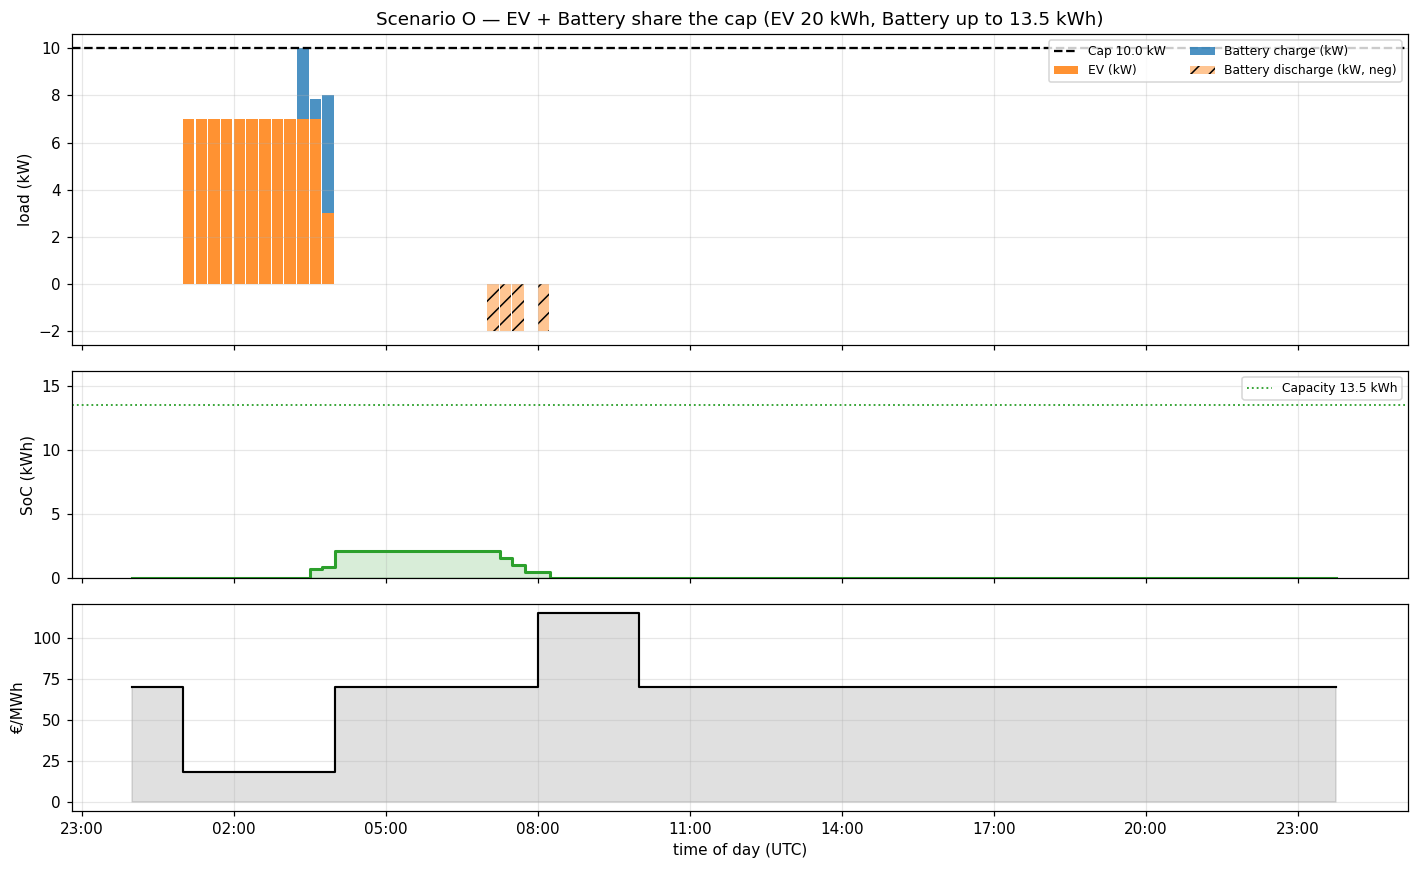

In [14]:
prices_O = np.full(96, 70.0)
prices_O[4:16] = 18.0       # 01:00–04:00 cheap trough
prices_O[32:40] = 115.0     # 08:00–10:00 morning peak

now_O = _utc(0)
bspec_O = BatterySpec()

sched_O = solve_receding_horizon(
    now_O, prices_O,
    horizon_slots=96,
    remaining_ev_kwh=20.0,
    battery_spec=bspec_O,
    initial_soc_kwh=0.0,
)

ev_O  = np.asarray(sched_O.ev_power_kw, dtype=float)
chg_O = np.asarray(sched_O.battery_charge_kw, dtype=float)
dis_O = np.asarray(sched_O.battery_discharge_kw, dtype=float)
soc_O = np.asarray(sched_O.soc_kwh, dtype=float)

# Net grid = EV + charge - discharge (base load omitted for clarity here)
net_O = ev_O + chg_O - dis_O
print(f"Max net grid draw:  {net_O.max():.3f} kW  (cap {HOUSE_POWER_CAP_KW} kW)")
print(f"EV total kWh:       {ev_O.sum() * SLOT_H:.3f}")
print(f"Battery peak SoC:   {soc_O.max():.3f} kWh")
print(f"Solver status:      {sched_O.solver_status}")
assert net_O.max() <= HOUSE_POWER_CAP_KW + 1e-4, "Net grid draw exceeded cap"
assert ev_O.sum() * SLOT_H >= 20.0 - 1e-3, "EV didn't get its full 20 kWh"

T = 96
times_O = [now_O + __import__('datetime').timedelta(minutes=15 * i) for i in range(T)]
width_days = 15 * 0.9 / (60 * 24)

fig_O, (ax_o1, ax_o2, ax_o3) = plt.subplots(3, 1, figsize=(13, 8), sharex=True,
                                               gridspec_kw={"height_ratios": [3, 2, 2]})

# Stacked load: EV (orange) + battery charge (blue) − battery discharge (below zero)
bottom_pos = np.zeros(T)
ax_o1.bar(times_O, ev_O, width=width_days, bottom=bottom_pos,
          color="#ff7f0e", alpha=0.85, align="edge", label="EV (kW)")
bottom_pos += ev_O
ax_o1.bar(times_O, chg_O, width=width_days, bottom=bottom_pos,
          color="#1f77b4", alpha=0.8, align="edge", label="Battery charge (kW)")

# Discharge shown below zero
ax_o1.bar(times_O, -dis_O, width=width_days,
          color="#ff7f0e", alpha=0.45, align="edge", label="Battery discharge (kW, neg)", hatch="//")

ax_o1.axhline(HOUSE_POWER_CAP_KW, color="black", ls="--", lw=1.5,
              label=f"Cap {HOUSE_POWER_CAP_KW} kW")
ax_o1.set_ylabel("load (kW)")
ax_o1.set_title("Scenario O — EV + Battery share the cap (EV 20 kWh, Battery up to 13.5 kWh)")
ax_o1.legend(fontsize=8, loc="upper right", ncol=2)

# SoC trajectory
ax_o2.step(times_O, soc_O, where="post", color="#2ca02c", lw=2.0)
ax_o2.fill_between(times_O, soc_O, step="post", alpha=0.18, color="#2ca02c")
ax_o2.axhline(bspec_O.capacity_kwh, color="#2ca02c", ls=":", lw=1.2,
              label=f"Capacity {bspec_O.capacity_kwh} kWh")
ax_o2.set_ylabel("SoC (kWh)")
ax_o2.set_ylim(0, bspec_O.capacity_kwh * 1.2)
ax_o2.legend(fontsize=8)

# Price
ax_o3.step(times_O, prices_O, where="post", color="k", lw=1.4)
ax_o3.fill_between(times_O, prices_O, step="post", alpha=0.12, color="k")
ax_o3.set_ylabel("€/MWh")
ax_o3.set_xlabel("time of day (UTC)")
ax_o3.xaxis.set_major_locator(__import__('matplotlib').dates.HourLocator(interval=3))
ax_o3.xaxis.set_major_formatter(__import__('matplotlib').dates.DateFormatter("%H:%M"))
fig_O.autofmt_xdate(rotation=0, ha="center")
plt.tight_layout()
plt.show()


## Scenario P — Home Battery savings: with vs. without (the headline benefit)

The previous two scenarios showed *how* the battery moves energy around.
This one measures *what it's worth*. We solve the **same realistic day twice**
— once with `battery_spec=None`, once with a 13.5 kWh `BatterySpec()` — under
identical prices, the same EV (24 kWh overnight), the heater windows, and the
deterministic **Base Load** (evening peak). Everything is held fixed except the
battery, so the difference in `expected_cost` is the battery's marginal value.

The price curve is a typical spring shape: a cheap overnight trough
(€22/MWh, 00:00–07:00), an expensive daytime plateau (€110/MWh), and a
moderate evening (€60/MWh). The EV and the battery both charge in the cheap
trough; the battery then discharges through the expensive day to cover the
Base Load and the heater's daytime window — load the no-battery plan has no
choice but to buy at the peak price.

The top panel overlays the **net grid draw** of both plans: the battery plan
buys *more* overnight (filling the pack) and *less* during the day (living off
stored energy). The gap between the grey and blue curves during the expensive
hours is the saving.


Expected bill WITHOUT battery : €1.7023
Expected bill WITH battery    : €0.9040
Battery saves                 : €0.7983  (46.9% off the total bill)


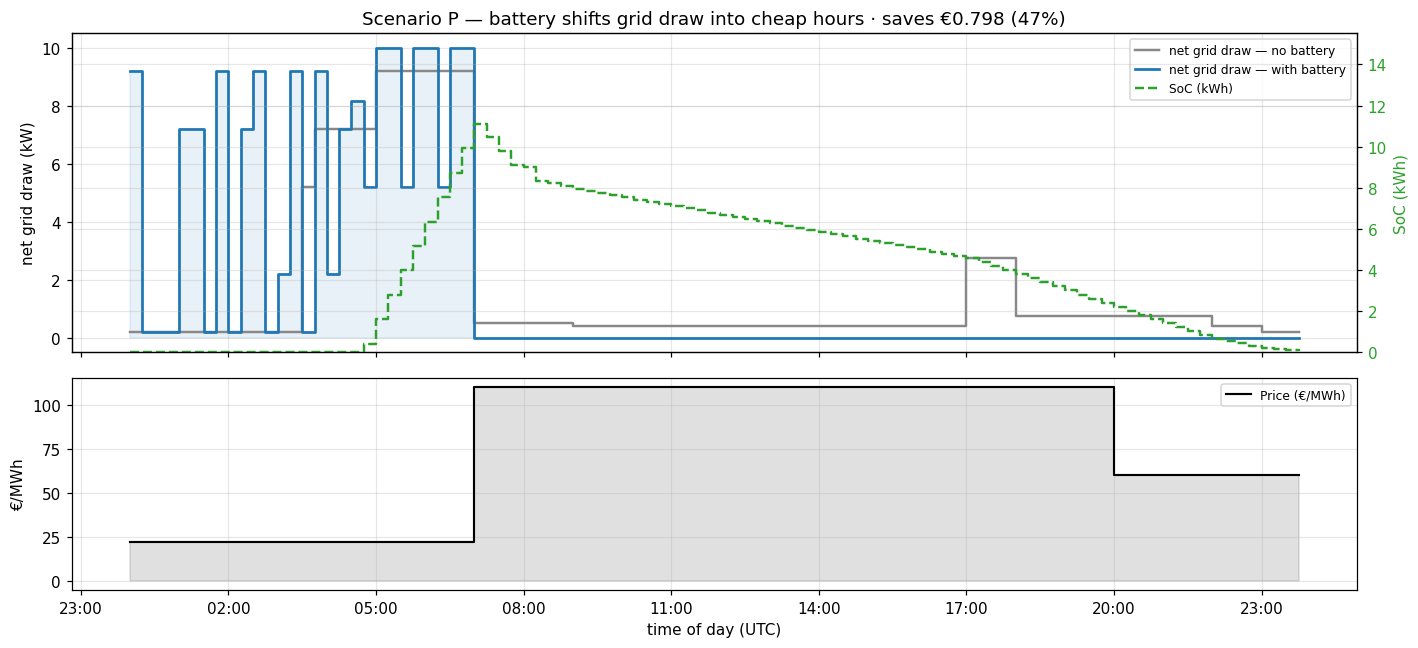

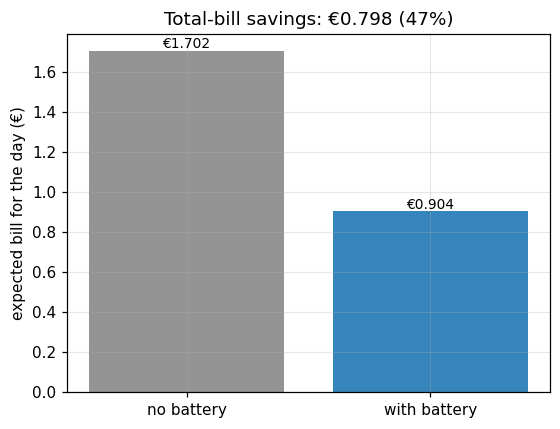

In [15]:
from aerogrid.config import get_base_load_kw

# A realistic spring day: cheap overnight (EV + battery charge), expensive
# daytime, moderate evening. Base Load (evening peak) + heater + EV all run.
prices_P = np.full(96, 110.0)
prices_P[0:28]  = 22.0     # 00:00–07:00 cheap overnight trough
prices_P[80:96] = 60.0     # 20:00–24:00 moderate evening

now_P  = _utc(0)
base_P = np.asarray(get_base_load_kw(now_P, 96))
bspec_P = BatterySpec()
width_days = SLOT_MINUTES * 0.9 / (60.0 * 24.0)

common_P = dict(
    now=now_P, prices=prices_P, horizon_slots=96,
    remaining_ev_kwh=24.0, base_load_kw=base_P,
)
sched_P_nobatt = solve_receding_horizon(**common_P, battery_spec=None)
sched_P_batt   = solve_receding_horizon(**common_P, battery_spec=bspec_P, initial_soc_kwh=0.0)

cost_no  = sched_P_nobatt.expected_cost
cost_bat = sched_P_batt.expected_cost
saved    = cost_no - cost_bat
print(f"Expected bill WITHOUT battery : €{cost_no:.4f}")
print(f"Expected bill WITH battery    : €{cost_bat:.4f}")
print(f"Battery saves                 : €{saved:.4f}  ({saved / cost_no * 100:.1f}% off the total bill)")

# Net grid draw for each plan = controllable loads + base load + charge − discharge.
def _net_grid_P(s):
    net = np.asarray(s.ev_power_kw) + np.asarray(s.heater_power_kw) + base_P
    if s.battery_charge_kw:
        net = net + np.asarray(s.battery_charge_kw) - np.asarray(s.battery_discharge_kw)
    return net

net_no  = _net_grid_P(sched_P_nobatt)
net_bat = _net_grid_P(sched_P_batt)
soc_P   = np.asarray(sched_P_batt.soc_kwh)

assert cost_bat < cost_no, "Battery must lower the expected bill"
assert soc_P.max() <= bspec_P.capacity_kwh + 1e-6

# ── net grid draw (no-batt vs batt) + SoC, with the price curve below ──
times_P = [now_P + timedelta(minutes=SLOT_MINUTES * i) for i in range(96)]

fig_P, (axp1, axp2) = plt.subplots(
    2, 1, figsize=(13, 6), sharex=True, gridspec_kw={"height_ratios": [3, 2]},
)
axp1.step(times_P, net_no, where="post", color="#888888", lw=1.6,
          label="net grid draw — no battery")
axp1.step(times_P, net_bat, where="post", color="#1f77b4", lw=1.8,
          label="net grid draw — with battery")
axp1.fill_between(times_P, net_bat, step="post", alpha=0.10, color="#1f77b4")
ax_soc = axp1.twinx()
ax_soc.step(times_P, soc_P, where="post", color="#2ca02c", lw=1.6, ls="--",
            label="SoC (kWh)")
ax_soc.set_ylim(0, bspec_P.capacity_kwh * 1.15)
ax_soc.set_ylabel("SoC (kWh)", color="#2ca02c")
ax_soc.tick_params(axis="y", labelcolor="#2ca02c")
axp1.set_ylabel("net grid draw (kW)")
axp1.set_title(
    f"Scenario P — battery shifts grid draw into cheap hours · "
    f"saves €{saved:.3f} ({saved / cost_no * 100:.0f}%)"
)
l1, la1 = axp1.get_legend_handles_labels()
l2, la2 = ax_soc.get_legend_handles_labels()
axp1.legend(l1 + l2, la1 + la2, fontsize=8, loc="upper right")

axp2.step(times_P, prices_P, where="post", color="k", lw=1.4, label="Price (€/MWh)")
axp2.fill_between(times_P, prices_P, step="post", alpha=0.12, color="k")
axp2.set_ylabel("€/MWh")
axp2.set_xlabel("time of day (UTC)")
axp2.legend(fontsize=8)
axp2.xaxis.set_major_locator(mdates.HourLocator(interval=3))
axp2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig_P.autofmt_xdate(rotation=0, ha="center")
plt.tight_layout()
plt.show()

# Headline cost comparison bars.
fig_Pb, axpb = plt.subplots(figsize=(5.2, 4))
axpb.bar(["no battery", "with battery"], [cost_no, cost_bat],
         color=["#888888", "#1f77b4"], alpha=0.9)
axpb.set_ylabel("expected bill for the day (€)")
axpb.set_title(f"Total-bill savings: €{saved:.3f} ({saved / cost_no * 100:.0f}%)")
for i, v in enumerate([cost_no, cost_bat]):
    axpb.text(i, v * 1.01, f"€{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


## Scenario Q — Connection-limit peak shaving (a benefit that has nothing to do with price)

The battery's second benefit (ADR 0001) is independent of arbitrage: because
discharging *relaxes* the net-import cap, the house can briefly draw more total
internal power than the grid connection allows, with the battery supplying the
excess. That lets time-critical load finish on deadline even when the grid cap
alone would throttle it.

To isolate this from any price effect, prices are **flat** (€50/MWh
everywhere). The EV must deliver **17.5 kWh** — exactly its rated 7 kW over the
2.5 h until the 07:00 deadline — but the grid cap is a tight **8 kW**, and the
Base Load eats into that headroom. Without a battery the EV is throttled and
misses its deadline (slack). With a **pre-charged battery (13.0 kWh)** the
optimiser runs the EV at full rated power and lets the battery cover the part
that pushes gross internal load above 8 kW — **net grid draw never crosses the
cap**.

In the plot, the stacked bars (EV + heater + Base Load) rise *above* the dashed
cap line, while the blue **net grid draw** line stays at or below it — the
difference is what the battery is supplying.


EV need by 07:00          : 17.50 kWh
  delivered, no battery   : 15.50 kWh   (throttled by the 8 kW cap)
  delivered, with battery : 17.50 kWh   (battery relaxes the cap)
Max GROSS internal load   : no-batt 8.00 kW · batt 9.20 kW (may exceed cap)
Max NET grid draw         : no-batt 8.00 kW · batt 4.80 kW (must stay ≤ 8)


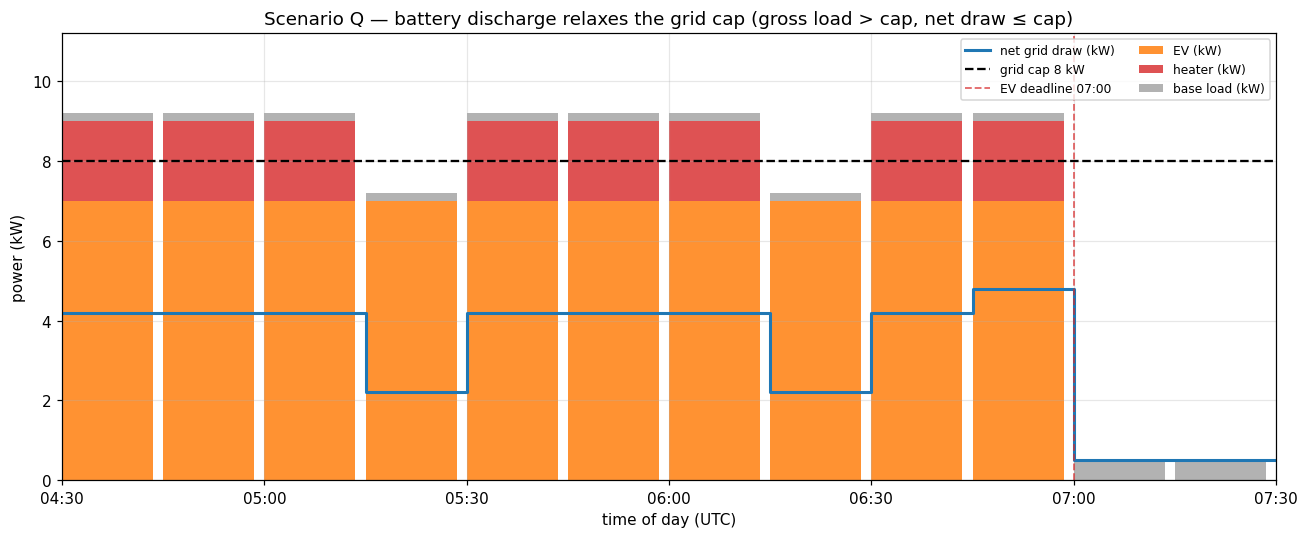

In [16]:
# Connection-limit peak shaving (ADR 0001). Flat price → the only benefit on
# show is the cap relief, not arbitrage.
prices_Q = np.full(96, 50.0)
now_Q  = _utc(4, 30)                # 2.5 h to the 07:00 EV deadline
base_Q = np.asarray(get_base_load_kw(now_Q, 96))
CAP_Q  = 8.0
EV_NEED_Q = 17.5                    # = EV rated 7 kW × 2.5 h: only reachable if the cap doesn't bind
width_days = SLOT_MINUTES * 0.9 / (60.0 * 24.0)

common_Q = dict(
    now=now_Q, prices=prices_Q, horizon_slots=96, remaining_ev_kwh=EV_NEED_Q,
    time_to_deadline_h=2.5, house_cap_kw=CAP_Q, base_load_kw=base_Q,
)
sched_Q_nobatt = solve_receding_horizon(**common_Q, battery_spec=None)
sched_Q_batt   = solve_receding_horizon(**common_Q, battery_spec=BatterySpec(), initial_soc_kwh=13.0)

DEADLINE_SLOTS = 10                 # 2.5 h / 0.25 h
def _ev_by_deadline(s):
    return np.asarray(s.ev_power_kw)[:DEADLINE_SLOTS].sum() * SLOT_H
def _gross_net_Q(s):
    gross = np.asarray(s.ev_power_kw) + np.asarray(s.heater_power_kw) + base_Q
    net = gross.copy()
    if s.battery_charge_kw:
        net = gross + np.asarray(s.battery_charge_kw) - np.asarray(s.battery_discharge_kw)
    return gross, net

ev_no  = _ev_by_deadline(sched_Q_nobatt)
ev_bat = _ev_by_deadline(sched_Q_batt)
gross_no,  net_no  = _gross_net_Q(sched_Q_nobatt)
gross_bat, net_bat = _gross_net_Q(sched_Q_batt)

print(f"EV need by 07:00          : {EV_NEED_Q:.2f} kWh")
print(f"  delivered, no battery   : {ev_no:.2f} kWh   (throttled by the {CAP_Q:.0f} kW cap)")
print(f"  delivered, with battery : {ev_bat:.2f} kWh   (battery relaxes the cap)")
print(f"Max GROSS internal load   : no-batt {gross_no.max():.2f} kW · batt {gross_bat.max():.2f} kW (may exceed cap)")
print(f"Max NET grid draw         : no-batt {net_no.max():.2f} kW · batt {net_bat.max():.2f} kW (must stay ≤ {CAP_Q:.0f})")

assert ev_bat > ev_no + 1e-3, "Battery should let more EV energy land before the deadline"
assert net_bat.max() <= CAP_Q + 1e-4, "Net grid draw must stay under the cap"
assert gross_bat.max() > CAP_Q + 1e-3, "Gross internal load should exceed the cap (battery supplies the excess)"

# ── gross stacked load vs net grid draw for the battery plan (zoomed) ──
times_Q  = [now_Q + timedelta(minutes=SLOT_MINUTES * i) for i in range(96)]
ev_arr   = np.asarray(sched_Q_batt.ev_power_kw)
ht_arr   = np.asarray(sched_Q_batt.heater_power_kw)
zoom_end = now_Q + timedelta(hours=3)
ev_deadline = now_Q + timedelta(hours=2.5)

fig_Q, axq = plt.subplots(figsize=(12, 5))
axq.bar(times_Q, ev_arr, width=width_days, color="#ff7f0e", align="edge",
        alpha=0.85, label="EV (kW)")
axq.bar(times_Q, ht_arr, width=width_days, bottom=ev_arr, color="#d62728",
        align="edge", alpha=0.8, label="heater (kW)")
axq.bar(times_Q, base_Q, width=width_days, bottom=ev_arr + ht_arr, color="#7f7f7f",
        align="edge", alpha=0.6, label="base load (kW)")
axq.step(times_Q, net_bat, where="post", color="#1f77b4", lw=2.0,
         label="net grid draw (kW)")
axq.axhline(CAP_Q, color="black", ls="--", lw=1.5, label=f"grid cap {CAP_Q:.0f} kW")
axq.axvline(ev_deadline, color="#d62728", ls="--", lw=1.2, alpha=0.7,
            label="EV deadline 07:00")
axq.set_xlim(now_Q, zoom_end)
axq.set_ylim(0, CAP_Q * 1.4)
axq.set_ylabel("power (kW)")
axq.set_xlabel("time of day (UTC)")
axq.set_title("Scenario Q — battery discharge relaxes the grid cap (gross load > cap, net draw ≤ cap)")
axq.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
axq.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axq.legend(fontsize=8, loc="upper right", ncol=2)
fig_Q.autofmt_xdate(rotation=0, ha="center")
plt.tight_layout()
plt.show()


## Scenario R — How much battery do you need? Savings vs. capacity

A natural follow-up to Scenario P: if 13.5 kWh saves ~47%, would a bigger pack
save more? We sweep usable capacity from **0 → 20 kWh** on the *same* day as
Scenario P (reusing `common_P`) and plot savings off the total bill.

Savings rise steeply at first — each extra kWh of storage offsets another slice
of expensive daytime load — then **plateau**: once the pack can already cover
all the offsettable peak load (Base Load + heater daytime window) from the
overnight trough, extra capacity sits idle and pays for nothing. The peak SoC
reached saturates at the same point. The plateau lands right around the
shipped 13.5 kWh, confirming that capacity is well matched to this household's
demand rather than arbitrarily large.


,capacity_kWh,expected_€,saved_€,saved_%,peak_SoC_kWh
0,0.0,1.7023,0.0000,0.0,0.00
1,1.0,1.6210,0.0813,4.8,1.00
2,2.0,1.5396,0.1627,9.6,2.00
3,3.5,1.4176,0.2847,16.7,3.50
4,5.0,1.2956,0.4067,23.9,5.00
5,6.5,1.1736,0.5287,31.1,6.50
6,8.0,1.0516,0.6507,38.2,8.00
7,10.0,0.9414,0.7609,44.7,10.00
8,13.5,0.9040,0.7983,46.9,11.11
9,16.0,0.9040,0.7983,46.9,11.11


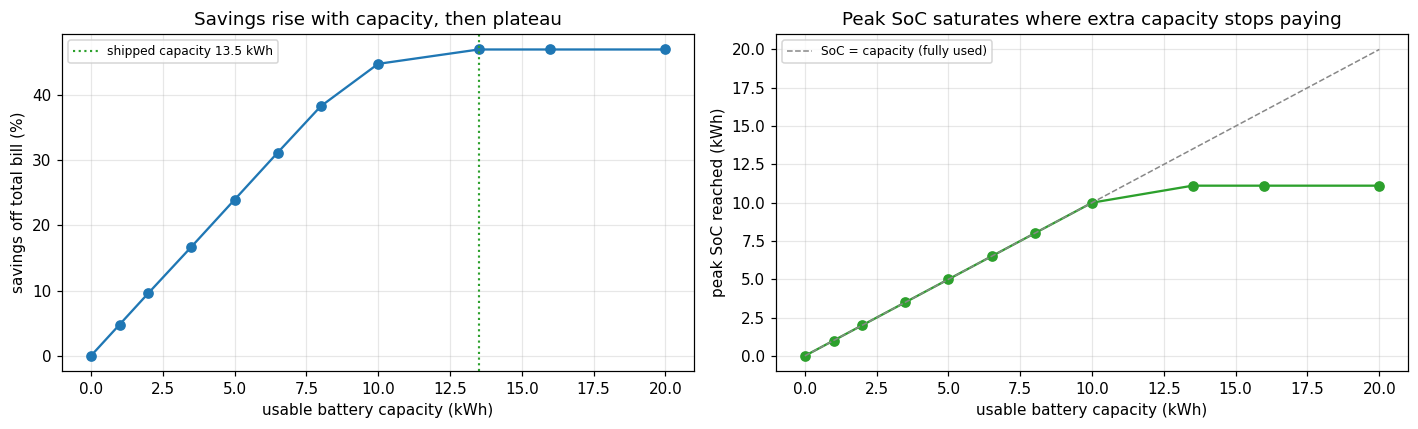

Savings plateau at ~13.5 kWh — extra capacity beyond this offsets no more peak load.


In [17]:
# Sweep usable capacity on the same realistic day as Scenario P.
caps_R = [0.0, 1.0, 2.0, 3.5, 5.0, 6.5, 8.0, 10.0, 13.5, 16.0, 20.0]
base_cost_R = solve_receding_horizon(**common_P, battery_spec=None).expected_cost

rows_R = []
for cap in caps_R:
    if cap <= 0.0:
        cost, soc_max = base_cost_R, 0.0
    else:
        s = solve_receding_horizon(
            **common_P, battery_spec=BatterySpec(capacity_kwh=cap), initial_soc_kwh=0.0,
        )
        cost = s.expected_cost
        soc_max = max(s.soc_kwh) if s.soc_kwh else 0.0
    rows_R.append({
        "capacity_kWh": cap,
        "expected_€": round(cost, 4),
        "saved_€": round(base_cost_R - cost, 4),
        "saved_%": round((1 - cost / base_cost_R) * 100, 1),
        "peak_SoC_kWh": round(soc_max, 2),
    })
df_R = pd.DataFrame(rows_R)
display(df_R)

fig_R, (axr1, axr2) = plt.subplots(1, 2, figsize=(13, 4))
axr1.plot(df_R["capacity_kWh"], df_R["saved_%"], "o-", color="#1f77b4")
axr1.axvline(BatterySpec().capacity_kwh, color="#2ca02c", ls=":", lw=1.4,
             label=f"shipped capacity {BatterySpec().capacity_kwh} kWh")
axr1.set_xlabel("usable battery capacity (kWh)")
axr1.set_ylabel("savings off total bill (%)")
axr1.set_title("Savings rise with capacity, then plateau")
axr1.legend(fontsize=8)
axr2.plot(df_R["capacity_kWh"], df_R["peak_SoC_kWh"], "o-", color="#2ca02c")
axr2.plot([0, df_R["capacity_kWh"].max()], [0, df_R["capacity_kWh"].max()],
          color="#888", ls="--", lw=1.0, label="SoC = capacity (fully used)")
axr2.set_xlabel("usable battery capacity (kWh)")
axr2.set_ylabel("peak SoC reached (kWh)")
axr2.set_title("Peak SoC saturates where extra capacity stops paying")
axr2.legend(fontsize=8)
plt.tight_layout()
plt.show()

knee = df_R[df_R["saved_€"] >= df_R["saved_€"].max() - 1e-6]["capacity_kWh"].min()
print(f"Savings plateau at ~{knee:.1f} kWh — extra capacity beyond this offsets no more peak load.")


## Summary

| Scenario | Feature | Verdict |
|---|---|---|
| A | EV availability gate (C1 mask) | Charging is hard-zero outside 20:00–07:00 |
| B | EV deadline regimes (C2) | Inside-horizon hard, outside prorated × γ |
| C | Heater per-window energy (C3) | Both 4 kWh / 2 kWh windows fully met |
| D | Heater concentrates in cheap hours | Overnight 4 kWh shifts into the price valley |
| E | Power-cap binding (C5) | EV + heater share the 8 kW cap |
| F | Committed dishwasher (C5 + headroom) | EV + heater throttle during the cycle |
| I | HITL throughput stress | 8 onsets, mixed accept/decline, threshold filters spurious offers |
| J | Horizon sensitivity | 24 h LP is only ~3× slower than 6 h, savings improve with horizon |
| K | Heater infeasibility | Slack absorbs the impossible 100 kWh ask, LP stays optimal |
| L | Joint MIP vs price-only reschedule | Joint solve avoids cap-induced re-shuffle, lowers plan cost |
| M | Re-nudge before start | Deferred dishwasher is replanned after new onset (moves again) |
| N | Home Battery: trough charge / peak discharge | Battery fills during cheap slots, empties at expensive peaks; SoC bounded |
| O | Battery + EV co-optimisation | Joint LP shares cap between EV and battery; net draw ≤ cap |
| P | Home Battery savings (with vs. without) | Same day, battery off vs on; battery shifts draw to cheap hours, ~47% off the bill |
| Q | Connection-limit peak shaving (ADR 0001) | Discharge relaxes the cap: gross load > cap, net grid draw ≤ cap, EV makes deadline |
| R | Savings vs. battery capacity | Savings rise then plateau ~13.5 kWh; shipped capacity matches household demand |

All scenarios are deterministic given their seeds — rerunning produces identical results.
